# Évaluation du modèle Camembert NER


Ce notebook évalue les performances du modèle `CamembertNERModel`, qui extrait les villes de départ (B-DEP, I-DEP)
et de destination (B-ARR, I-ARR) à partir des textes d'entrée. Les performances sont analysées à l'aide de métriques,
de visualisations des prédictions et d'analyses détaillées.


## Visualisation des métriques de performance

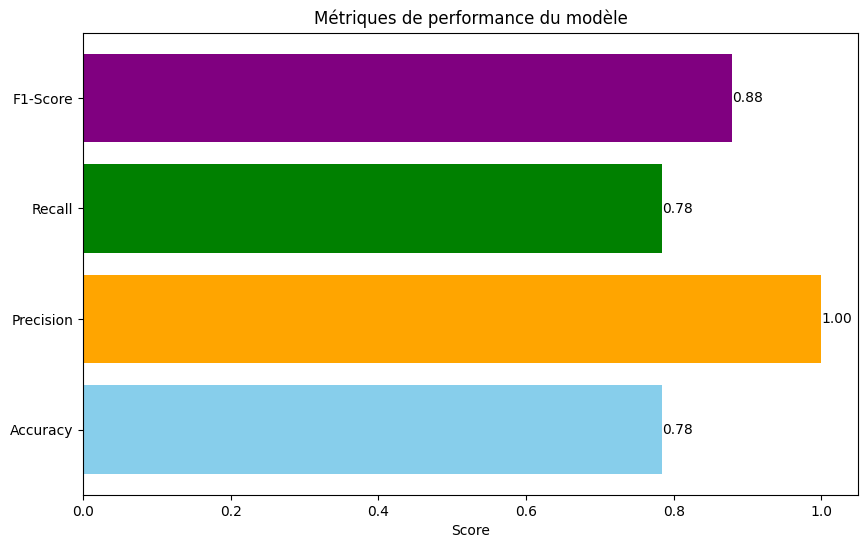

In [1]:

import matplotlib.pyplot as plt
import json

# Charger les métriques
metrics = json.loads('''{"Accuracy": 0.7846724559480651, "Precision": 1.0, "Recall": 0.7846724559480651, "F1-Score": 0.8793461829176115}''')

# Visualiser les métriques
plt.figure(figsize=(10, 6))
plt.barh(list(metrics.keys()), list(metrics.values()), color=['skyblue', 'orange', 'green', 'purple'])
plt.xlabel("Score")
plt.title("Métriques de performance du modèle")
for i, (key, val) in enumerate(metrics.items()):
    plt.text(val, i, f"{val:.2f}", va='center')
plt.show()


## Matrice de confusion

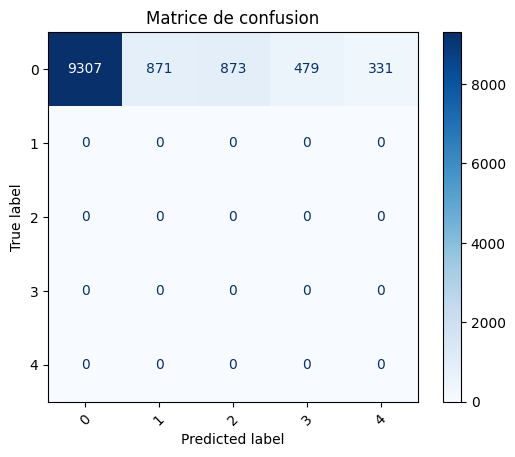

In [2]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import json

all_true_labels = json.loads('''[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]''')
all_predicted_labels = json.loads('''[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0]''')

# Classes attendues
classes = sorted(set(all_true_labels + all_predicted_labels))
cm = confusion_matrix(all_true_labels, all_predicted_labels, labels=classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Matrice de confusion")
plt.show()


## Courbe ROC

In [3]:

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import warnings

# Vérifier s'il existe des échantillons positifs
if len(set(all_true_labels)) > 1:
    fpr, tpr, _ = roc_curve(all_true_labels, all_predicted_labels, pos_label=1)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='blue', label=f"Courbe ROC (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
    plt.xlabel("Taux de faux positifs (FPR)")
    plt.ylabel("Taux de vrais positifs (TPR)")
    plt.title("Courbe ROC")
    plt.legend()
    plt.grid()
    plt.show()
else:
    warnings.warn("Pas de classes positives, courbe ROC non applicable.")


C:\Users\leogu\AppData\Local\Temp\ipykernel_28060\2593737757.py:20: UserWarning: Pas de classes positives, courbe ROC non applicable.
  warnings.warn("Pas de classes positives, courbe ROC non applicable.")


## Distribution des scores de probabilité

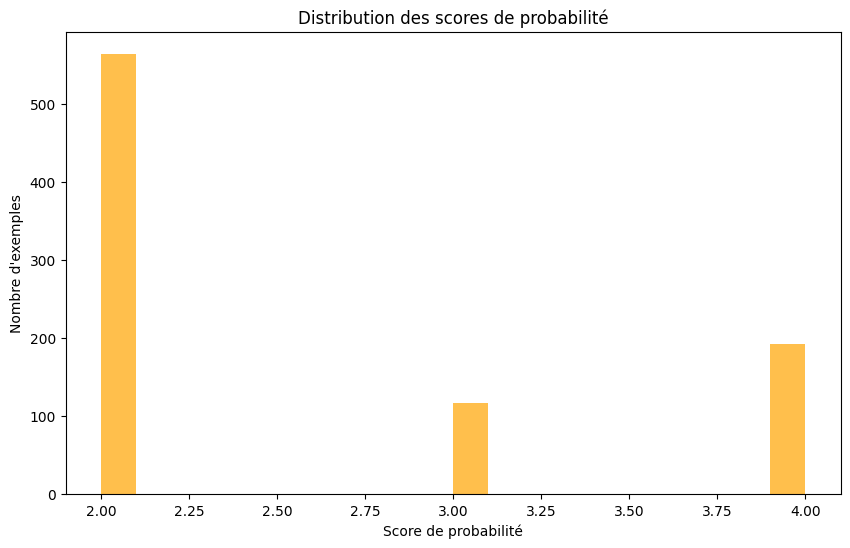

In [4]:

import matplotlib.pyplot as plt
import json

results = json.loads('''[{"text": "Elle cherche un itin\u00e9raire jusqu'\u00e0 Nice \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581cherche", "\u2581un", "\u2581itin\u00e9raire", "\u2581jusqu", "'", "\u00e0", "\u2581Nice", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je veux aller de Biarritz \u00e0 Marseille", "tokens": ["<s>", "\u2581Je", "\u2581veux", "\u2581aller", "\u2581de", "\u2581Biarritz", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de partir de Lyon \u00e0 Toulouse demain", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581partir", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Toulouse", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0]}, {"text": "Nous r\u00e9servons un billet pour un trajet de Bordeaux \u00e0 Nantes", "tokens": ["<s>", "\u2581Nous", "\u2581r\u00e9serv", "ons", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Nantes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle va prendre le train de Strasbourg \u00e0 Lille", "tokens": ["<s>", "\u2581Elle", "\u2581va", "\u2581prendre", "\u2581le", "\u2581train", "\u2581de", "\u2581Strasbourg", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il part de Montpellier pour aller \u00e0 Lyon", "tokens": ["<s>", "\u2581Il", "\u2581part", "\u2581de", "\u2581Montpellier", "\u2581pour", "\u2581aller", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Elle cherche un vol de Paris \u00e0 Nice", "tokens": ["<s>", "\u2581Elle", "\u2581cherche", "\u2581un", "\u2581vol", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il prend l'avion pour un trajet entre Lyon et Marseille", "tokens": ["<s>", "\u2581Il", "\u2581prend", "\u2581l", "'", "avion", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581entre", "\u2581Lyon", "\u2581et", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de partir de Toulouse pour visiter Bordeaux", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581partir", "\u2581de", "\u2581Toulouse", "\u2581pour", "\u2581visiter", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Je cherche un itin\u00e9raire en train de Nantes \u00e0 Rennes", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581itin\u00e9raire", "\u2581en", "\u2581train", "\u2581de", "\u2581Nantes", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous devons partir demain matin de Marseille \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Nous", "\u2581devons", "\u2581partir", "\u2581demain", "\u2581matin", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je dois rejoindre mes amis de Bordeaux \u00e0 Paris", "tokens": ["<s>", "\u2581Je", "\u2581dois", "\u2581rejoindre", "\u2581mes", "\u2581amis", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il a pr\u00e9vu de voyager de Lille \u00e0 Toulouse", "tokens": ["<s>", "\u2581Il", "\u2581a", "\u2581pr\u00e9vu", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je pars de Nice pour un s\u00e9jour \u00e0 Paris", "tokens": ["<s>", "\u2581Je", "\u2581par", "s", "\u2581de", "\u2581Nice", "\u2581pour", "\u2581un", "\u2581s\u00e9jour", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Rennes \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Ils veulent un trajet de Marseille \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Ils", "\u2581veulent", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle se rendra de Strasbourg \u00e0 Lille en train", "tokens": ["<s>", "\u2581Elle", "\u2581se", "\u2581rendra", "\u2581de", "\u2581Strasbourg", "\u2581\u00e0", "\u2581Lille", "\u2581en", "\u2581train", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0]}, {"text": "Nous allons en voiture de Toulouse \u00e0 Montpellier", "tokens": ["<s>", "\u2581Nous", "\u2581allons", "\u2581en", "\u2581voiture", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Montpellier", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il cherche un vol de Bordeaux \u00e0 Paris", "tokens": ["<s>", "\u2581Il", "\u2581cherche", "\u2581un", "\u2581vol", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle a pr\u00e9vu un trajet de Marseille \u00e0 Nantes", "tokens": ["<s>", "\u2581Elle", "\u2581a", "\u2581pr\u00e9vu", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Nantes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Ils prennent un train de Rennes \u00e0 Lyon ce soir", "tokens": ["<s>", "\u2581Ils", "\u2581prennent", "\u2581un", "\u2581train", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Lyon", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0]}, {"text": "Nous partons demain matin de Paris \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581demain", "\u2581matin", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il a achet\u00e9 un billet de Toulouse \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Il", "\u2581a", "\u2581achet\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend l'avion de Nice \u00e0 Lyon la semaine prochaine", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581l", "'", "avion", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Lyon", "\u2581la", "\u2581semaine", "\u2581prochaine", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0]}, {"text": "Nous cherchons un trajet de Nantes \u00e0 Paris", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Nantes", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il voyage de Lille \u00e0 Marseille pour un \u00e9v\u00e9nement", "tokens": ["<s>", "\u2581Il", "\u2581voyage", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Marseille", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0]}, {"text": "Elle prend le train de Rennes \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581le", "\u2581train", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je pr\u00e9vois de partir de Paris pour aller \u00e0 Lyon", "tokens": ["<s>", "\u2581Je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581partir", "\u2581de", "\u2581Paris", "\u2581pour", "\u2581aller", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Nous cherchons un itin\u00e9raire de Toulouse \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit un trajet de Lille \u00e0 Nice", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il part en train de Rennes \u00e0 Paris", "tokens": ["<s>", "\u2581Il", "\u2581part", "\u2581en", "\u2581train", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous allons voyager de Marseille \u00e0 Toulouse", "tokens": ["<s>", "\u2581Nous", "\u2581allons", "\u2581voyager", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je cherche un billet de train de Bordeaux \u00e0 Nantes", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Nantes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle a r\u00e9serv\u00e9 un vol de Paris \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581a", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581vol", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il doit rejoindre un client de Strasbourg \u00e0 Lyon", "tokens": ["<s>", "\u2581Il", "\u2581doit", "\u2581rejoindre", "\u2581un", "\u2581client", "\u2581de", "\u2581Strasbourg", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons pr\u00e9vu de partir de Lille \u00e0 Rennes", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581pr\u00e9vu", "\u2581de", "\u2581partir", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je dois prendre un avion de Marseille \u00e0 Paris", "tokens": ["<s>", "\u2581Je", "\u2581dois", "\u2581prendre", "\u2581un", "\u2581avion", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle part de Lyon pour visiter Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581part", "\u2581de", "\u2581Lyon", "\u2581pour", "\u2581visiter", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Nous cherchons un itin\u00e9raire de train de Bordeaux \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de partir de Paris \u00e0 Rennes", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581partir", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut prendre un train de Lille \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581prendre", "\u2581un", "\u2581train", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons un voyage de Rennes \u00e0 Paris", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je vais voyager de Toulouse \u00e0 Lille", "tokens": ["<s>", "\u2581Je", "\u2581vais", "\u2581voyager", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle doit rejoindre des coll\u00e8gues de Paris \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581doit", "\u2581rejoindre", "\u2581des", "\u2581coll\u00e8gues", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un trajet en train de Bordeaux \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581trajet", "\u2581en", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il prend un avion de Nice \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Il", "\u2581prend", "\u2581un", "\u2581avion", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle part de Rennes pour visiter Nantes", "tokens": ["<s>", "\u2581Elle", "\u2581part", "\u2581de", "\u2581Rennes", "\u2581pour", "\u2581visiter", "\u2581Nantes", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Nous r\u00e9servons un billet de Paris \u00e0 Toulouse", "tokens": ["<s>", "\u2581Nous", "\u2581r\u00e9serv", "ons", "\u2581un", "\u2581billet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit un vol de Lyon \u00e0 Lille", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un train de Bordeaux \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Toulouse \u00e0 Rennes", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je pr\u00e9vois de prendre un train de Paris \u00e0 Nice", "tokens": ["<s>", "\u2581Je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581prendre", "\u2581un", "\u2581train", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons demain de Lille \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581demain", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut r\u00e9server un billet de Rennes \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581r\u00e9server", "\u2581un", "\u2581billet", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je dois aller de Paris \u00e0 Nantes", "tokens": ["<s>", "\u2581Je", "\u2581dois", "\u2581aller", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Nantes", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit un voyage de Marseille \u00e0 Lille", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons pris un billet de Toulouse \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581pris", "\u2581un", "\u2581billet", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il part en voiture de Lille \u00e0 Paris", "tokens": ["<s>", "\u2581Il", "\u2581part", "\u2581en", "\u2581voiture", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je prends un vol de Marseille \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Je", "\u2581prends", "\u2581un", "\u2581vol", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle part en train de Bordeaux \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581part", "\u2581en", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous r\u00e9servons un billet de Lyon \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581r\u00e9serv", "ons", "\u2581un", "\u2581billet", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Toulouse \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un itin\u00e9raire de train de Rennes \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581train", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il prend un avion de Marseille \u00e0 Nantes", "tokens": ["<s>", "\u2581Il", "\u2581prend", "\u2581un", "\u2581avion", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Nantes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de partir de Paris \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581partir", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous allons de Lyon \u00e0 Bordeaux demain", "tokens": ["<s>", "\u2581Nous", "\u2581allons", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Bordeaux", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 2, 0, 0]}, {"text": "Il prend un train de Lille \u00e0 Toulouse", "tokens": ["<s>", "\u2581Il", "\u2581prend", "\u2581un", "\u2581train", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle cherche un trajet de Rennes \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581cherche", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons un voyage de Bordeaux \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je dois aller de Paris \u00e0 Marseille demain", "tokens": ["<s>", "\u2581Je", "\u2581dois", "\u2581aller", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Marseille", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0, 0]}, {"text": "Elle pr\u00e9voit de rejoindre ses amis de Lille \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581rejoindre", "\u2581ses", "\u2581amis", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il part de Rennes pour un \u00e9v\u00e9nement \u00e0 Paris", "tokens": ["<s>", "\u2581Il", "\u2581part", "\u2581de", "\u2581Rennes", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous r\u00e9servons un billet de Marseille \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581r\u00e9serv", "ons", "\u2581un", "\u2581billet", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un avion de Toulouse \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je pars de Paris pour visiter Rennes", "tokens": ["<s>", "\u2581Je", "\u2581par", "s", "\u2581de", "\u2581Paris", "\u2581pour", "\u2581visiter", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Nous cherchons un trajet de train de Lille \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581trajet", "\u2581de", "\u2581train", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il voyage de Rennes \u00e0 Nice", "tokens": ["<s>", "\u2581Il", "\u2581voyage", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je cherche un billet de train de Paris \u00e0 Marseille", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Bordeaux \u00e0 Lyon demain", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Lyon", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0]}, {"text": "Nous avons un vol pr\u00e9vu de Toulouse \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581pr\u00e9vu", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il prend le bus de Rennes \u00e0 Strasbourg ce soir", "tokens": ["<s>", "\u2581Il", "\u2581prend", "\u2581le", "\u2581bus", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Strasbourg", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0]}, {"text": "Elle veut un itin\u00e9raire de train de Lille \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581train", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je dois partir de Lyon pour une r\u00e9union \u00e0 Marseille", "tokens": ["<s>", "\u2581Je", "\u2581dois", "\u2581partir", "\u2581de", "\u2581Lyon", "\u2581pour", "\u2581une", "\u2581r\u00e9union", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous avons un billet de train pour un voyage de Nantes \u00e0 Paris", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Nantes", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de prendre le train de Marseille \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581prendre", "\u2581le", "\u2581train", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je cherche un itin\u00e9raire de Bordeaux \u00e0 Nice", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de partir de Rennes pour visiter Lille", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581partir", "\u2581de", "\u2581Rennes", "\u2581pour", "\u2581visiter", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle prend un avion de Toulouse \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous allons voyager de Lyon \u00e0 Bordeaux demain", "tokens": ["<s>", "\u2581Nous", "\u2581allons", "\u2581voyager", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Bordeaux", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0, 0]}, {"text": "Il part en train de Paris \u00e0 Nice", "tokens": ["<s>", "\u2581Il", "\u2581part", "\u2581en", "\u2581train", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut r\u00e9server un billet de Rennes \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581r\u00e9server", "\u2581un", "\u2581billet", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je pr\u00e9vois de prendre le train de Nantes \u00e0 Lyon", "tokens": ["<s>", "\u2581Je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581prendre", "\u2581le", "\u2581train", "\u2581de", "\u2581Nantes", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un vol pr\u00e9vu de Lille \u00e0 Toulouse", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581pr\u00e9vu", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle doit rejoindre des amis de Marseille \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581doit", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de voyager de Bordeaux \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un itin\u00e9raire de Rennes \u00e0 Toulouse", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un billet pour un trajet de Nice \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je veux partir de Lyon pour un \u00e9v\u00e9nement \u00e0 Paris", "tokens": ["<s>", "\u2581Je", "\u2581veux", "\u2581partir", "\u2581de", "\u2581Lyon", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Il partira demain de Toulouse \u00e0 Lille", "tokens": ["<s>", "\u2581Il", "\u2581partir", "a", "\u2581demain", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un train de Rennes \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581train", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous r\u00e9servons un vol de Marseille \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581r\u00e9serv", "ons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il veut voyager de Paris \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Il", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit un trajet de Bordeaux \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un billet pour un voyage de Lille \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre ses coll\u00e8gues de Rennes \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581ses", "\u2581coll\u00e8gues", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je dois partir de Marseille pour un s\u00e9jour \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Je", "\u2581dois", "\u2581partir", "\u2581de", "\u2581Marseille", "\u2581pour", "\u2581un", "\u2581s\u00e9jour", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Il prend le bus de Nice \u00e0 Toulouse ce soir", "tokens": ["<s>", "\u2581Il", "\u2581prend", "\u2581le", "\u2581bus", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Toulouse", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0]}, {"text": "Elle pr\u00e9voit de voyager de Lyon \u00e0 Rennes demain", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Rennes", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0]}, {"text": "Nous r\u00e9servons un vol de Paris \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581r\u00e9serv", "ons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle partira en train de Bordeaux \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581partir", "a", "\u2581en", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de rejoindre des amis de Rennes \u00e0 Nice", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un trajet pr\u00e9vu de Toulouse \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581trajet", "\u2581pr\u00e9vu", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle doit partir de Paris pour un \u00e9v\u00e9nement \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581doit", "\u2581partir", "\u2581de", "\u2581Paris", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je cherche un itin\u00e9raire de Rennes \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il part de Lille pour un s\u00e9jour \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Il", "\u2581part", "\u2581de", "\u2581Lille", "\u2581pour", "\u2581un", "\u2581s\u00e9jour", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Elle prend un avion de Nice \u00e0 Lyon la semaine prochaine", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Lyon", "\u2581la", "\u2581semaine", "\u2581prochaine", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0]}, {"text": "Nous pr\u00e9voyons de prendre le train de Bordeaux \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581prendre", "\u2581le", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre des amis de Paris \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Marseille \u00e0 Rennes", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de partir de Lyon pour visiter Lille", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581partir", "\u2581de", "\u2581Lyon", "\u2581pour", "\u2581visiter", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Je pars de Rennes pour un voyage \u00e0 Paris", "tokens": ["<s>", "\u2581Je", "\u2581par", "s", "\u2581de", "\u2581Rennes", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Elle prend un billet de train de Toulouse \u00e0 Nice", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous r\u00e9servons un vol de Bordeaux \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Nous", "\u2581r\u00e9serv", "ons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il cherche un itin\u00e9raire de Paris \u00e0 Lyon", "tokens": ["<s>", "\u2581Il", "\u2581cherche", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de rejoindre ses coll\u00e8gues de Lille \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581rejoindre", "\u2581ses", "\u2581coll\u00e8gues", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous devons partir de Nice pour un \u00e9v\u00e9nement \u00e0 Rennes", "tokens": ["<s>", "\u2581Nous", "\u2581devons", "\u2581partir", "\u2581de", "\u2581Nice", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je cherche un vol de Toulouse \u00e0 Paris", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581vol", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle a pr\u00e9vu de voyager de Bordeaux \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581a", "\u2581pr\u00e9vu", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un billet pour un trajet de Lyon \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut partir de Lille pour visiter Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581partir", "\u2581de", "\u2581Lille", "\u2581pour", "\u2581visiter", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Je pr\u00e9vois de prendre le train de Marseille \u00e0 Paris", "tokens": ["<s>", "\u2581Je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581prendre", "\u2581le", "\u2581train", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il prend un bus de Bordeaux \u00e0 Nice ce soir", "tokens": ["<s>", "\u2581Il", "\u2581prend", "\u2581un", "\u2581bus", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Nice", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0]}, {"text": "Elle pr\u00e9voit un itin\u00e9raire de Rennes \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous allons partir de Lyon pour un \u00e9v\u00e9nement \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581allons", "\u2581partir", "\u2581de", "\u2581Lyon", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Elle veut prendre un billet de train de Nice \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581prendre", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de rejoindre des amis de Marseille \u00e0 Rennes", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je cherche un trajet de Toulouse \u00e0 Lyon", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un avion de Bordeaux \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Lille \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de voyager de Rennes \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut prendre un vol de Lyon \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581prendre", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je cherche un billet de train de Marseille \u00e0 Lille", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un vol de Paris \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581vol", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581partir", "a", "\u2581de", "\u2581Nice", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Il pr\u00e9voit un voyage de Toulouse \u00e0 Marseille", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un trajet de Lille \u00e0 Paris pr\u00e9vu", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Paris", "\u2581pr\u00e9vu", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0]}, {"text": "Elle veut rejoindre ses amis de Rennes \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581ses", "\u2581amis", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je pars de Bordeaux pour visiter Marseille", "tokens": ["<s>", "\u2581Je", "\u2581par", "s", "\u2581de", "\u2581Bordeaux", "\u2581pour", "\u2581visiter", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Il pr\u00e9voit de prendre un bus de Lyon \u00e0 Nice", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581prendre", "\u2581un", "\u2581bus", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle a r\u00e9serv\u00e9 un billet pour un trajet de Paris \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581a", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Marseille \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Lille \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je cherche un billet de train de Rennes \u00e0 Marseille", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de prendre un vol de Toulouse \u00e0 Paris", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581prendre", "\u2581un", "\u2581vol", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit un trajet de Nice \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il part de Bordeaux pour un s\u00e9jour \u00e0 Lille", "tokens": ["<s>", "\u2581Il", "\u2581part", "\u2581de", "\u2581Bordeaux", "\u2581pour", "\u2581un", "\u2581s\u00e9jour", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Elle prend un billet pour un trajet de Rennes \u00e0 Nice", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un vol de Paris \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581vol", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il cherche un itin\u00e9raire de Marseille \u00e0 Toulouse", "tokens": ["<s>", "\u2581Il", "\u2581cherche", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut partir de Strasbourg pour un s\u00e9jour \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581partir", "\u2581de", "\u2581Strasbourg", "\u2581pour", "\u2581un", "\u2581s\u00e9jour", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je pr\u00e9vois de prendre le bus de Nice \u00e0 Paris", "tokens": ["<s>", "\u2581Je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581prendre", "\u2581le", "\u2581bus", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de rejoindre ses amis de Lille \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581rejoindre", "\u2581ses", "\u2581amis", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous r\u00e9servons un vol de Toulouse \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581r\u00e9serv", "ons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il veut partir de Rennes pour visiter Marseille", "tokens": ["<s>", "\u2581Il", "\u2581veut", "\u2581partir", "\u2581de", "\u2581Rennes", "\u2581pour", "\u2581visiter", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Je prends un billet de train de Bordeaux \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Je", "\u2581prends", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Lyon \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un billet pour un trajet de Lille \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle doit rejoindre des coll\u00e8gues de Rennes \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581doit", "\u2581rejoindre", "\u2581des", "\u2581coll\u00e8gues", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je cherche un vol de Marseille \u00e0 Paris", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581vol", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de partir de Lyon pour un \u00e9v\u00e9nement \u00e0 Toulouse", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581partir", "\u2581de", "\u2581Lyon", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Elle prend un train de Bordeaux \u00e0 Lille", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Paris \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre des amis de Nice \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de voyager de Toulouse \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je pars de Rennes pour visiter Marseille", "tokens": ["<s>", "\u2581Je", "\u2581par", "s", "\u2581de", "\u2581Rennes", "\u2581pour", "\u2581visiter", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle pr\u00e9voit un trajet de Lyon \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Marseille \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il cherche un itin\u00e9raire de Bordeaux \u00e0 Toulouse", "tokens": ["<s>", "\u2581Il", "\u2581cherche", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre ses amis de Lille \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581ses", "\u2581amis", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de partir de Paris pour visiter Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581partir", "\u2581de", "\u2581Paris", "\u2581pour", "\u2581visiter", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle prend un vol de Nice \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581vol", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je dois aller de Marseille \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Je", "\u2581dois", "\u2581aller", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il veut un billet de train de Rennes \u00e0 Toulouse", "tokens": ["<s>", "\u2581Il", "\u2581veut", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Lyon \u00e0 Marseille demain", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Marseille", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0]}, {"text": "Nous cherchons un vol de Paris \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit un trajet de Bordeaux \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons demain de Toulouse \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581demain", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il prend un billet pour un trajet de Paris \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Il", "\u2581prend", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit un voyage de Marseille \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je cherche un itin\u00e9raire de train de Bordeaux \u00e0 Paris", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un billet pour un trajet de Lille \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Rennes \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de partir de Paris pour un \u00e9v\u00e9nement \u00e0 Nice", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581partir", "\u2581de", "\u2581Paris", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Elle prend un vol de Bordeaux \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581vol", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Marseille \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de partir de Lille \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581partir", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je cherche un vol de Toulouse \u00e0 Rennes", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581vol", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Bordeaux \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut prendre un vol de Nice \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581prendre", "\u2581un", "\u2581vol", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de rejoindre des amis de Paris \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Lyon \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut partir de Marseille pour un s\u00e9jour \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581partir", "\u2581de", "\u2581Marseille", "\u2581pour", "\u2581un", "\u2581s\u00e9jour", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je cherche un billet de train de Lille \u00e0 Rennes", "tokens": ["<s>", "\u2581Je", "\u2581cherche", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de prendre le bus de Paris \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581prendre", "\u2581le", "\u2581bus", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit un trajet de Bordeaux \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il part de Nice pour un \u00e9v\u00e9nement \u00e0 Lyon", "tokens": ["<s>", "\u2581Il", "\u2581part", "\u2581de", "\u2581Nice", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Elle prend un billet pour un trajet de Rennes \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous r\u00e9servons un vol de Paris \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Nous", "\u2581r\u00e9serv", "ons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il cherche un itin\u00e9raire de Marseille \u00e0 Nice", "tokens": ["<s>", "\u2581Il", "\u2581cherche", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut partir de Toulouse pour un s\u00e9jour \u00e0 Lille", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581partir", "\u2581de", "\u2581Toulouse", "\u2581pour", "\u2581un", "\u2581s\u00e9jour", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de voyager de Rennes \u00e0 Paris", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un vol de Bordeaux \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581vol", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Je pr\u00e9vois de partir de Lyon pour visiter Toulouse", "tokens": ["<s>", "\u2581Je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581partir", "\u2581de", "\u2581Lyon", "\u2581pour", "\u2581visiter", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle veut rejoindre des coll\u00e8gues de Nice \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581coll\u00e8gues", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Lille \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de voyager de Marseille \u00e0 Lyon", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un billet de train de Rennes \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un trajet de Paris \u00e0 Nice pr\u00e9vu", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Nice", "\u2581pr\u00e9vu", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0]}, {"text": "Il pr\u00e9voit un voyage de Marseille \u00e0 Rennes", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un billet pour un trajet de Lille \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un vol de Bordeaux \u00e0 Toulouse", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre des amis de Paris \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il cherche un itin\u00e9raire de Lyon \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Il", "\u2581cherche", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de prendre le train de Rennes \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581prendre", "\u2581le", "\u2581train", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Toulouse \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut prendre un billet de Marseille \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581prendre", "\u2581un", "\u2581billet", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de partir de Lille pour visiter Lyon", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581partir", "\u2581de", "\u2581Lille", "\u2581pour", "\u2581visiter", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle prend un avion de Bordeaux \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Paris \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle part de Rennes pour un s\u00e9jour \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581part", "\u2581de", "\u2581Rennes", "\u2581pour", "\u2581un", "\u2581s\u00e9jour", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Il cherche un vol de Marseille \u00e0 Lyon", "tokens": ["<s>", "\u2581Il", "\u2581cherche", "\u2581un", "\u2581vol", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Bordeaux \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous r\u00e9servons un vol de Lille \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581r\u00e9serv", "ons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut partir de Toulouse pour un \u00e9v\u00e9nement \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581partir", "\u2581de", "\u2581Toulouse", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons un trajet de Nice \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un billet pour un voyage de Paris \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit de rejoindre des amis de Marseille \u00e0 Nice", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581de", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Lille \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un vol de Rennes \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un billet pour un trajet de Bordeaux \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Paris \u00e0 Toulouse", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de partir de Marseille pour visiter Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581partir", "\u2581de", "\u2581Marseille", "\u2581pour", "\u2581visiter", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Il prend un avion de Lyon \u00e0 Lille", "tokens": ["<s>", "\u2581Il", "\u2581prend", "\u2581un", "\u2581avion", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Nice \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Bordeaux \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un vol pour un trajet de Toulouse \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581vol", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Lille \u00e0 Rennes", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Marseille \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il cherche un itin\u00e9raire de Paris \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Il", "\u2581cherche", "\u2581un", "\u2581itin\u00e9raire", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un billet pour un trajet de Rennes \u00e0 Nice", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un vol de Toulouse \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre des amis de Lyon \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Bordeaux \u00e0 Paris", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle part de Nice pour un s\u00e9jour \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581part", "\u2581de", "\u2581Nice", "\u2581pour", "\u2581un", "\u2581s\u00e9jour", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de partir de Rennes pour visiter Bordeaux", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581partir", "\u2581de", "\u2581Rennes", "\u2581pour", "\u2581visiter", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle prend un billet de train pour un trajet de Toulouse \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un vol de Lille \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Marseille \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit un trajet de Paris \u00e0 Rennes", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un avion pour un voyage de Nice \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Bordeaux \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Lille \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Paris \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre ses coll\u00e8gues de Rennes \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581ses", "\u2581coll\u00e8gues", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Toulouse \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581partir", "a", "\u2581de", "\u2581Nice", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Il pr\u00e9voit un trajet de Lille \u00e0 Paris", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un billet pour un voyage de Marseille \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un vol de Rennes \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de rejoindre des amis de Paris \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de partir de Bordeaux pour visiter Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581partir", "\u2581de", "\u2581Bordeaux", "\u2581pour", "\u2581visiter", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle prend un billet de train pour un trajet de Toulouse \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un vol de Lille \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Lyon \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit un trajet de Rennes \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un avion pour un voyage de Bordeaux \u00e0 Lille", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Nice \u00e0 Toulouse", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Paris \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Marseille \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre des coll\u00e8gues de Toulouse \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581coll\u00e8gues", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Lille \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle partira de Lyon pour un \u00e9v\u00e9nement \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581partir", "a", "\u2581de", "\u2581Lyon", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de partir de Rennes pour visiter Paris", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581partir", "\u2581de", "\u2581Rennes", "\u2581pour", "\u2581visiter", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle prend un billet de train pour un trajet de Toulouse \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un vol de Bordeaux \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Nice \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit un trajet de Paris \u00e0 Lille", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un avion pour un voyage de Marseille \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Toulouse \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Rennes \u00e0 Nice", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Lyon \u00e0 Paris", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre des coll\u00e8gues de Bordeaux \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581coll\u00e8gues", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Lille \u00e0 Rennes", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581partir", "a", "\u2581de", "\u2581Nice", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de partir de Paris pour visiter Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581partir", "\u2581de", "\u2581Paris", "\u2581pour", "\u2581visiter", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle prend un billet de train pour un trajet de Bordeaux \u00e0 Nice", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un vol de Marseille \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Toulouse \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit un trajet de Rennes \u00e0 Paris", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un avion pour un voyage de Lyon \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Bordeaux \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Nice \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Paris \u00e0 Rennes", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre des amis de Marseille \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Toulouse \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle partira de Bordeaux pour un \u00e9v\u00e9nement \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581partir", "a", "\u2581de", "\u2581Bordeaux", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de partir de Lille pour visiter Paris", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581partir", "\u2581de", "\u2581Lille", "\u2581pour", "\u2581visiter", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle prend un billet de train pour un trajet de Marseille \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un vol de Rennes \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Nice \u00e0 Lille", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit un trajet de Paris \u00e0 Marseille", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un avion pour un voyage de Toulouse \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Lyon \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Lille \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Rennes \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre des coll\u00e8gues de Bordeaux \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581coll\u00e8gues", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Toulouse \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581partir", "a", "\u2581de", "\u2581Nice", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de partir de Marseille pour visiter Rennes", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581partir", "\u2581de", "\u2581Marseille", "\u2581pour", "\u2581visiter", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle prend un billet de train pour un trajet de Bordeaux \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un vol de Lille \u00e0 Nice", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Toulouse \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit un trajet de Paris \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un avion pour un voyage de Rennes \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Marseille \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Nice \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Lyon \u00e0 Rennes", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre des amis de Bordeaux \u00e0 Marseille", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Toulouse \u00e0 Paris", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581partir", "a", "\u2581de", "\u2581Nice", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de partir de Marseille pour visiter Lille", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581partir", "\u2581de", "\u2581Marseille", "\u2581pour", "\u2581visiter", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle prend un billet de train pour un trajet de Bordeaux \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un vol de Lille \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Toulouse \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit un trajet de Paris \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un avion pour un voyage de Nice \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Marseille \u00e0 Paris", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Rennes \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Lyon \u00e0 Lille", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre des amis de Bordeaux \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Toulouse \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle partira de Nice pour un \u00e9v\u00e9nement \u00e0 Lille", "tokens": ["<s>", "\u2581Elle", "\u2581partir", "a", "\u2581de", "\u2581Nice", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Nous pr\u00e9voyons de partir de Paris pour visiter Bordeaux", "tokens": ["<s>", "\u2581Nous", "\u2581pr\u00e9", "voy", "ons", "\u2581de", "\u2581partir", "\u2581de", "\u2581Paris", "\u2581pour", "\u2581visiter", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0]}, {"text": "Elle prend un billet de train pour un trajet de Marseille \u00e0 Rennes", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581billet", "\u2581de", "\u2581train", "\u2581pour", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons un vol de Lille \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut voyager de Toulouse \u00e0 Lyon", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581voyager", "\u2581de", "\u2581Toulouse", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Il pr\u00e9voit un trajet de Nice \u00e0 Bordeaux", "tokens": ["<s>", "\u2581Il", "\u2581pr\u00e9voit", "\u2581un", "\u2581trajet", "\u2581de", "\u2581Nice", "\u2581\u00e0", "\u2581Bordeaux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle prend un avion pour un voyage de Rennes \u00e0 Toulouse", "tokens": ["<s>", "\u2581Elle", "\u2581prend", "\u2581un", "\u2581avion", "\u2581pour", "\u2581un", "\u2581voyage", "\u2581de", "\u2581Rennes", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous partons en train de Paris \u00e0 Lyon", "tokens": ["<s>", "\u2581Nous", "\u2581partons", "\u2581en", "\u2581train", "\u2581de", "\u2581Paris", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle pr\u00e9voit de voyager de Marseille \u00e0 Lille", "tokens": ["<s>", "\u2581Elle", "\u2581pr\u00e9voit", "\u2581de", "\u2581voyager", "\u2581de", "\u2581Marseille", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous avons r\u00e9serv\u00e9 un billet de Bordeaux \u00e0 Paris", "tokens": ["<s>", "\u2581Nous", "\u2581avons", "\u2581r\u00e9serv\u00e9", "\u2581un", "\u2581billet", "\u2581de", "\u2581Bordeaux", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle veut rejoindre des amis de Lyon \u00e0 Nice", "tokens": ["<s>", "\u2581Elle", "\u2581veut", "\u2581rejoindre", "\u2581des", "\u2581amis", "\u2581de", "\u2581Lyon", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Nous cherchons un vol de Lille \u00e0 Marseille", "tokens": ["<s>", "\u2581Nous", "\u2581cherchons", "\u2581un", "\u2581vol", "\u2581de", "\u2581Lille", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 2, 0]}, {"text": "Elle partira de Toulouse pour un \u00e9v\u00e9nement \u00e0 Paris", "tokens": ["<s>", "\u2581Elle", "\u2581partir", "a", "\u2581de", "\u2581Toulouse", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", "\u2581\u00e0", "\u2581Paris", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je passe la journ\u00e9e \u00e0 Bayonne, retour \u00e0 Pau ensuite", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581journ\u00e9e", "\u2581\u00e0", "\u2581Bayonne", ",", "\u2581retour", "\u2581\u00e0", "\u2581Pau", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Orl\u00e9ans, retour \u00e0 Blois demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Orl\u00e9ans", ",", "\u2581retour", "\u2581\u00e0", "\u2581Blois", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "En visite \u00e0 Chartres, retour pr\u00e9vu \u00e0 Dreux ce soir", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Chartres", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581D", "reux", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0]}, {"text": "Je suis \u00e0 Rennes pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Saint-Malo demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Rennes", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Saint", "-", "Malo", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je suis en vacances \u00e0 Saint-Nazaire, retour \u00e0 Nantes ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Saint", "-", "Nazaire", ",", "\u2581retour", "\u2581\u00e0", "\u2581Nantes", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0]}, {"text": "En visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581", "Ajaccio", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Bastia", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement \u00e0 Amiens pour le travail, retour pr\u00e9vu \u00e0 Beauvais ensuite", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Amiens", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Beauvais", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Toulon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Thionville, retour pr\u00e9vu \u00e0 Metz demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Thi", "on", "ville", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Metz", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En vacances \u00e0 Narbonne, retour pr\u00e9vu \u00e0 Carcassonne", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Narbonne", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Carcassonne", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Alen\u00e7on pour le travail, retour pr\u00e9vu \u00e0 Argentan ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Al", "en", "\u00e7on", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Argent", "an", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En visite \u00e0 Montauban, retour \u00e0 Toulouse demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Montauban", ",", "\u2581retour", "\u2581\u00e0", "\u2581Toulouse", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Lannion, retour \u00e0 Morlaix pr\u00e9vu demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581La", "nni", "on", ",", "\u2581retour", "\u2581\u00e0", "\u2581Morlaix", "\u2581pr\u00e9vu", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Actuellement en visite \u00e0 Poitiers, je rentre \u00e0 Niort ensuite", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Poitiers", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Niort", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Besan\u00e7on, retour pr\u00e9vu \u00e0 Dole", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Besan\u00e7on", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Dol", "e", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis \u00e0 Lorient pour quelques jours, retour pr\u00e9vu \u00e0 Vannes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Lorient", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vannes", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Mulhouse, retour pr\u00e9vu \u00e0 Colmar ce soir", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Mulhouse", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Colmar", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Lille, retour pr\u00e9vu \u00e0 Roubaix", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Lille", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Roubaix", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Arles, retour pr\u00e9vu \u00e0 N\u00eemes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581", "Arles", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581N\u00eemes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en visite \u00e0 Vichy, retour pr\u00e9vu \u00e0 Moulins demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Vichy", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Moulin", "s", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En d\u00e9placement \u00e0 P\u00e9rigueux, retour \u00e0 Bergerac", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581P\u00e9rigueux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bergerac", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Tarbes pour le travail, retour \u00e0 Pau pr\u00e9vu demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Tarbes", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581\u00e0", "\u2581Pau", "\u2581pr\u00e9vu", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "En visite \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille ce soir", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Toulon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Marseille", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Actuellement \u00e0 Paris pour une r\u00e9union, retour pr\u00e9vu \u00e0 Versailles", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Paris", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Versailles", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Je passe la semaine \u00e0 Rouen, retour pr\u00e9vu \u00e0 Caen", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581semaine", "\u2581\u00e0", "\u2581Rouen", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Caen", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Thonon-les-Bains, retour \u00e0 Annecy", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Tho", "non", "-", "les", "-", "Bains", ",", "\u2581retour", "\u2581\u00e0", "\u2581", "Annecy", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en vacances \u00e0 Avignon, retour \u00e0 Aix-en-Provence", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Avignon", ",", "\u2581retour", "\u2581\u00e0", "\u2581Aix", "-", "en", "-", "Provence", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0]}, {"text": "En d\u00e9placement \u00e0 Troyes, retour \u00e0 Sens", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Troyes", ",", "\u2581retour", "\u2581\u00e0", "\u2581Sens", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Saint-Malo pour quelques jours, retour pr\u00e9vu \u00e0 Rennes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Saint", "-", "Malo", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement \u00e0 Reims pour le travail, retour \u00e0 Ch\u00e2lons", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Reims", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581\u00e0", "\u2581Ch\u00e2", "lons", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0]}, {"text": "En visite \u00e0 Pau, retour pr\u00e9vu \u00e0 Tarbes demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Pau", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Tarbes", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en vacances \u00e0 Saint-Quentin, retour pr\u00e9vu \u00e0 Laon", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Saint", "-", "Quentin", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581La", "on", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je passe quelques jours \u00e0 Le Havre, retour \u00e0 Rouen ensuite", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Le", "\u2581Havre", ",", "\u2581retour", "\u2581\u00e0", "\u2581Rouen", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Bayonne, retour pr\u00e9vu \u00e0 Pau", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Bayonne", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Pau", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Nancy, retour pr\u00e9vu \u00e0 Metz", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Nancy", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Metz", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Bourges pour le travail, retour pr\u00e9vu \u00e0 Vierzon", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Bourges", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vi", "er", "zon", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "En visite \u00e0 Tours, retour pr\u00e9vu \u00e0 Blois", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Tours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Blois", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement en visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581", "Ajaccio", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Bastia", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Quimper pour quelques jours, retour pr\u00e9vu \u00e0 Brest", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Quimper", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Brest", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Toulouse, retour pr\u00e9vu \u00e0 Albi", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Toulouse", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581", "Albi", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "En visite \u00e0 Limoges, retour \u00e0 Brive", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Limoges", ",", "\u2581retour", "\u2581\u00e0", "\u2581Brive", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Ch\u00e2teauroux, retour \u00e0 Bourges", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Ch\u00e2teau", "roux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bourges", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0]}, {"text": "Je passe la semaine \u00e0 Orl\u00e9ans, retour pr\u00e9vu \u00e0 Blois", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581semaine", "\u2581\u00e0", "\u2581Orl\u00e9ans", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Blois", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Lorient pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Vannes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Lorient", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vannes", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 La Rochelle, retour pr\u00e9vu \u00e0 Rochefort", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581La", "\u2581Rochelle", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Rochefort", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Calais, retour \u00e0 Boulogne-sur-Mer", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Calais", ",", "\u2581retour", "\u2581\u00e0", "\u2581Boulogne", "-", "sur", "-", "Mer", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0]}, {"text": "Actuellement en visite \u00e0 Metz, retour \u00e0 Nancy", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Metz", ",", "\u2581retour", "\u2581\u00e0", "\u2581Nancy", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Angoul\u00eame, retour pr\u00e9vu \u00e0 Cognac", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581", "Angoul\u00eame", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Cognac", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Perpignan, retour \u00e0 Narbonne", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Perpignan", ",", "\u2581retour", "\u2581\u00e0", "\u2581Narbonne", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je passe la journ\u00e9e \u00e0 Brest, retour \u00e0 Morlaix", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581journ\u00e9e", "\u2581\u00e0", "\u2581Brest", ",", "\u2581retour", "\u2581\u00e0", "\u2581Morlaix", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Dieppe, retour \u00e0 Rouen", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Dieppe", ",", "\u2581retour", "\u2581\u00e0", "\u2581Rouen", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Actuellement en visite \u00e0 Chamb\u00e9ry, retour \u00e0 Grenoble", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Chamb\u00e9ry", ",", "\u2581retour", "\u2581\u00e0", "\u2581Grenoble", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Brive, retour \u00e0 Tulle", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Brive", ",", "\u2581retour", "\u2581\u00e0", "\u2581Tu", "lle", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Annemasse, retour \u00e0 Thonon-les-Bains", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Anne", "m", "asse", ",", "\u2581retour", "\u2581\u00e0", "\u2581Tho", "non", "-", "les", "-", "Bains", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0]}, {"text": "Actuellement en visite \u00e0 Cannes, retour \u00e0 Nice", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Cannes", ",", "\u2581retour", "\u2581\u00e0", "\u2581Nice", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je passe la semaine \u00e0 Montlu\u00e7on, retour pr\u00e9vu \u00e0 Moulins", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581semaine", "\u2581\u00e0", "\u2581Mont", "lu", "\u00e7on", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Moulin", "s", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis \u00e0 Mulhouse pour le travail, retour pr\u00e9vu \u00e0 Colmar", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Mulhouse", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Colmar", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Dijon, retour pr\u00e9vu \u00e0 Beaune", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Dijon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Beau", "ne", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis \u00e0 Al\u00e8s pour quelques jours, retour \u00e0 N\u00eemes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581A", "l\u00e8s", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581\u00e0", "\u2581N\u00eemes", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En d\u00e9placement \u00e0 \u00c9vreux, retour \u00e0 Rouen", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581\u00c9", "v", "reux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Rouen", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "Actuellement en visite \u00e0 Lens, retour \u00e0 Arras", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Lens", ",", "\u2581retour", "\u2581\u00e0", "\u2581Ar", "ras", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0]}, {"text": "En vacances \u00e0 Agen, retour pr\u00e9vu \u00e0 Marmande", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581A", "gen", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Mar", "mand", "e", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "Je suis \u00e0 Angers pour le travail, retour \u00e0 Saumur", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Angers", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581\u00e0", "\u2581Saumur", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Morlaix, retour pr\u00e9vu \u00e0 Brest", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Morlaix", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Brest", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Albi, retour pr\u00e9vu \u00e0 Castres", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581", "Albi", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Cast", "res", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en vacances \u00e0 Cognac, retour \u00e0 Angoul\u00eame", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Cognac", ",", "\u2581retour", "\u2581\u00e0", "\u2581", "Angoul\u00eame", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0]}, {"text": "Je passe quelques jours \u00e0 Tulle, retour \u00e0 Brive", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Tu", "lle", ",", "\u2581retour", "\u2581\u00e0", "\u2581Brive", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Mende, retour \u00e0 Rodez", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Men", "de", ",", "\u2581retour", "\u2581\u00e0", "\u2581Rod", "ez", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0]}, {"text": "En vacances \u00e0 Saintes, retour pr\u00e9vu \u00e0 Rochefort", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Sainte", "s", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Rochefort", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Pontoise pour une r\u00e9union, retour \u00e0 Cergy", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Pont", "oise", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ",", "\u2581retour", "\u2581\u00e0", "\u2581C", "er", "gy", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Montargis, retour \u00e0 Orl\u00e9ans", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Mont", "arg", "is", ",", "\u2581retour", "\u2581\u00e0", "\u2581Orl\u00e9ans", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Laon, retour pr\u00e9vu \u00e0 Reims", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581La", "on", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Reims", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Bergerac, retour \u00e0 P\u00e9rigueux", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Bergerac", ",", "\u2581retour", "\u2581\u00e0", "\u2581P\u00e9rigueux", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je passe la journ\u00e9e \u00e0 Meaux, retour \u00e0 Melun", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581journ\u00e9e", "\u2581\u00e0", "\u2581M", "eaux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Mel", "un", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0]}, {"text": "En d\u00e9placement \u00e0 Gu\u00e9ret, retour \u00e0 La Souterraine", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Gu\u00e9", "ret", ",", "\u2581retour", "\u2581\u00e0", "\u2581La", "\u2581Sou", "terrain", "e", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 4, 0]}, {"text": "Actuellement en visite \u00e0 Tarascon, retour \u00e0 Avignon", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Tara", "s", "con", ",", "\u2581retour", "\u2581\u00e0", "\u2581Avignon", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Draguignan, retour \u00e0 Fr\u00e9jus", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Dra", "gu", "ignan", ",", "\u2581retour", "\u2581\u00e0", "\u2581Fr\u00e9jus", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Saint-L\u00f4, retour \u00e0 Coutances", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Saint", "-", "L", "\u00f4", ",", "\u2581retour", "\u2581\u00e0", "\u2581Cout", "ances", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 0]}, {"text": "Actuellement \u00e0 Oyonnax, retour pr\u00e9vu \u00e0 Bourg-en-Bresse", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581O", "y", "on", "na", "x", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Bourg", "-", "en", "-", "B", "resse", "</s>"], "predictions": [0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0]}, {"text": "Je suis \u00e0 S\u00e8te pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Montpellier", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581S", "\u00e8te", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Montpellier", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Al\u00e8s, retour \u00e0 N\u00eemes", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581A", "l\u00e8s", ",", "\u2581retour", "\u2581\u00e0", "\u2581N\u00eemes", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0]}, {"text": "Je passe quelques jours \u00e0 Ch\u00e2lons, retour \u00e0 Reims", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Ch\u00e2", "lons", ",", "\u2581retour", "\u2581\u00e0", "\u2581Reims", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Mont\u00e9limar, retour \u00e0 Valence", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Mont", "\u00e9li", "mar", ",", "\u2581retour", "\u2581\u00e0", "\u2581Valence", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Figeac, retour \u00e0 Cahors", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Fig", "e", "ac", ",", "\u2581retour", "\u2581\u00e0", "\u2581Ca", "hors", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0]}, {"text": "Je passe la semaine \u00e0 Maubeuge, retour \u00e0 Valenciennes", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581semaine", "\u2581\u00e0", "\u2581M", "aube", "uge", ",", "\u2581retour", "\u2581\u00e0", "\u2581Valenciennes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Saint-Malo, retour \u00e0 Rennes", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Saint", "-", "Malo", ",", "\u2581retour", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "Actuellement en visite \u00e0 Aurillac, retour \u00e0 Figeac", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Au", "r", "illac", ",", "\u2581retour", "\u2581\u00e0", "\u2581Fig", "e", "ac", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Lisieux, retour \u00e0 Caen", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Li", "s", "ieux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Caen", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Abbeville, retour \u00e0 Amiens", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Ab", "be", "ville", ",", "\u2581retour", "\u2581\u00e0", "\u2581Amiens", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 \u00c9pinal pour quelques jours, retour \u00e0 Nancy", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581\u00c9p", "in", "al", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581\u00e0", "\u2581Nancy", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement \u00e0 Villeneuve-sur-Lot, retour \u00e0 Agen", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Villeneuve", "-", "sur", "-", "L", "ot", ",", "\u2581retour", "\u2581\u00e0", "\u2581A", "gen", "</s>"], "predictions": [0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Haguenau, retour \u00e0 Strasbourg", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Ha", "guen", "au", ",", "\u2581retour", "\u2581\u00e0", "\u2581Strasbourg", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "Je passe quelques jours \u00e0 Auxerre, retour \u00e0 Sens", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581", "Auxerre", ",", "\u2581retour", "\u2581\u00e0", "\u2581Sens", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Issoire, retour \u00e0 Clermont-Ferrand", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Is", "s", "oire", ",", "\u2581retour", "\u2581\u00e0", "\u2581Clermont", "-", "Ferrand", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0]}, {"text": "Je passe quelques jours \u00e0 Saint-Omer, retour \u00e0 Dunkerque", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Saint", "-", "O", "mer", ",", "\u2581retour", "\u2581\u00e0", "\u2581Dunkerque", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Lannion, retour \u00e0 Morlaix", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581La", "nni", "on", ",", "\u2581retour", "\u2581\u00e0", "\u2581Morlaix", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "En d\u00e9placement pour le boulot \u00e0 Amiens, mais je rentre \u00e0 Beauvais ensuite", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581pour", "\u2581le", "\u2581boulot", "\u2581\u00e0", "\u2581Amiens", ",", "\u2581mais", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Beauvais", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Actuellement chez un ami \u00e0 Dijon, retour pr\u00e9vu \u00e0 M\u00e2con demain", "tokens": ["<s>", "\u2581Actuellement", "\u2581chez", "\u2581un", "\u2581ami", "\u2581\u00e0", "\u2581Dijon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581M", "\u00e2", "con", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Marseille avant de retourner sur Arles", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Marseille", "\u2581avant", "\u2581de", "\u2581retourner", "\u2581sur", "\u2581", "Arles", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en visite \u00e0 Lyon, mais je pr\u00e9vois de rentrer sur Villeurbanne", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Lyon", ",", "\u2581mais", "\u2581je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581rentrer", "\u2581sur", "\u2581Villeurbanne", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Pau, je rentre \u00e0 Tarbes ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Pau", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Tarbes", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Actuellement en visite \u00e0 Rennes, retour \u00e0 Saint-Brieuc ce soir", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Rennes", ",", "\u2581retour", "\u2581\u00e0", "\u2581Saint", "-", "Brieuc", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0]}, {"text": "Je suis \u00e0 Grenoble pour quelques jours, retour pr\u00e9vu \u00e0 Chamb\u00e9ry ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Grenoble", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Chamb\u00e9ry", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En d\u00e9placement \u00e0 Tours, je compte rentrer \u00e0 Blois", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Tours", ",", "\u2581je", "\u2581compte", "\u2581rentrer", "\u2581\u00e0", "\u2581Blois", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Nice pour le travail, retour pr\u00e9vu \u00e0 Menton demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Nice", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Men", "ton", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille apr\u00e8s-demain", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Toulon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Marseille", "\u2581apr\u00e8s", "-", "de", "main", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je reste \u00e0 Paris pour le moment, mais je rentre \u00e0 Versailles bient\u00f4t", "tokens": ["<s>", "\u2581Je", "\u2581reste", "\u2581\u00e0", "\u2581Paris", "\u2581pour", "\u2581le", "\u2581moment", ",", "\u2581mais", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Versailles", "\u2581bient\u00f4t", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En visite \u00e0 La Rochelle, retour \u00e0 Rochefort ce week-end", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581La", "\u2581Rochelle", ",", "\u2581retour", "\u2581\u00e0", "\u2581Rochefort", "\u2581ce", "\u2581week", "-", "end", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je suis \u00e0 Nantes pour une r\u00e9union, retour \u00e0 Angers ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Nantes", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ",", "\u2581retour", "\u2581\u00e0", "\u2581Angers", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En vacances \u00e0 Strasbourg, retour \u00e0 Colmar demain", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Strasbourg", ",", "\u2581retour", "\u2581\u00e0", "\u2581Colmar", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en visite \u00e0 N\u00eemes, retour pr\u00e9vu \u00e0 Avignon ce soir", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581N\u00eemes", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Avignon", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "En d\u00e9placement \u00e0 Poitiers, je rentre \u00e0 Niort ensuite", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Poitiers", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Niort", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en vacances \u00e0 Bordeaux, retour \u00e0 Arcachon ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Bordeaux", ",", "\u2581retour", "\u2581\u00e0", "\u2581", "Arcachon", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En visite \u00e0 Lille, retour pr\u00e9vu \u00e0 Dunkerque ce soir", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Lille", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Dunkerque", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Actuellement \u00e0 Limoges, je pr\u00e9vois de rentrer \u00e0 Brive demain", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Limoges", ",", "\u2581je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581rentrer", "\u2581\u00e0", "\u2581Brive", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis \u00e0 Rouen pour quelques jours, retour pr\u00e9vu \u00e0 Caen ce soir", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Rouen", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Caen", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "En visite \u00e0 Dijon, retour \u00e0 Chalon-sur-Sa\u00f4ne pr\u00e9vu demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Dijon", ",", "\u2581retour", "\u2581\u00e0", "\u2581Chalon", "-", "sur", "-", "Sa\u00f4ne", "\u2581pr\u00e9vu", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Amiens, retour pr\u00e9vu \u00e0 Beauvais ce soir", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Amiens", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Beauvais", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Je passe la journ\u00e9e \u00e0 Perpignan, retour pr\u00e9vu \u00e0 Carcassonne", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581journ\u00e9e", "\u2581\u00e0", "\u2581Perpignan", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Carcassonne", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Albi pour une conf\u00e9rence, retour \u00e0 Castres ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581", "Albi", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581\u00e0", "\u2581Cast", "res", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En vacances \u00e0 Cannes, retour pr\u00e9vu \u00e0 Nice demain", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Cannes", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Nice", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en visite \u00e0 Lyon, retour pr\u00e9vu \u00e0 Grenoble", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Lyon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Grenoble", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "En d\u00e9placement \u00e0 Saint-\u00c9tienne, je rentre \u00e0 Lyon demain", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Saint", "-", "\u00c9tienne", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Lyon", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en visite \u00e0 Metz, retour pr\u00e9vu \u00e0 Nancy ce soir", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Metz", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Nancy", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Actuellement en visite \u00e0 Mont-de-Marsan, je rentre \u00e0 Dax ensuite", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Mont", "-", "de", "-", "Mar", "san", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581D", "ax", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Lorient, retour pr\u00e9vu \u00e0 Vannes ce soir", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Lorient", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vannes", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "En visite \u00e0 Reims, retour pr\u00e9vu \u00e0 Ch\u00e2lons demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Reims", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Ch\u00e2", "lons", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Nevers, retour \u00e0 Moulins ensuite", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Never", "s", ",", "\u2581retour", "\u2581\u00e0", "\u2581Moulin", "s", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je suis en vacances \u00e0 Bastia, retour pr\u00e9vu \u00e0 Ajaccio demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Bastia", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581", "Ajaccio", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je reste \u00e0 Pau pour l\u2019instant, retour pr\u00e9vu \u00e0 Tarbes ce soir", "tokens": ["<s>", "\u2581Je", "\u2581reste", "\u2581\u00e0", "\u2581Pau", "\u2581pour", "\u2581l", "\u2019", "instant", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Tarbes", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "En visite \u00e0 Charleville-M\u00e9zi\u00e8res, retour pr\u00e9vu \u00e0 Sedan demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Char", "le", "ville", "-", "M\u00e9", "z", "i\u00e8res", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Se", "dan", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je suis \u00e0 Clermont-Ferrand pour le travail, retour pr\u00e9vu \u00e0 Moulins ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Clermont", "-", "Ferrand", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Moulin", "s", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Actuellement en d\u00e9placement \u00e0 Tours, retour pr\u00e9vu \u00e0 Blois ce soir", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Tours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Blois", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Je suis en visite \u00e0 Bourges, retour pr\u00e9vu \u00e0 Vierzon demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Bourges", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vi", "er", "zon", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je passe la journ\u00e9e \u00e0 Bayonne, retour \u00e0 Pau ensuite", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581journ\u00e9e", "\u2581\u00e0", "\u2581Bayonne", ",", "\u2581retour", "\u2581\u00e0", "\u2581Pau", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Orl\u00e9ans, retour \u00e0 Blois demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Orl\u00e9ans", ",", "\u2581retour", "\u2581\u00e0", "\u2581Blois", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "En visite \u00e0 Chartres, retour pr\u00e9vu \u00e0 Dreux ce soir", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Chartres", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581D", "reux", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0]}, {"text": "Je suis \u00e0 Rennes pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Saint-Malo demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Rennes", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Saint", "-", "Malo", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je suis en vacances \u00e0 Saint-Nazaire, retour \u00e0 Nantes ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Saint", "-", "Nazaire", ",", "\u2581retour", "\u2581\u00e0", "\u2581Nantes", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0]}, {"text": "En visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581", "Ajaccio", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Bastia", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement \u00e0 Amiens pour le travail, retour pr\u00e9vu \u00e0 Beauvais ensuite", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Amiens", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Beauvais", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Toulon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Thionville, retour pr\u00e9vu \u00e0 Metz demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Thi", "on", "ville", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Metz", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En vacances \u00e0 Narbonne, retour pr\u00e9vu \u00e0 Carcassonne", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Narbonne", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Carcassonne", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Alen\u00e7on pour le travail, retour pr\u00e9vu \u00e0 Argentan ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Al", "en", "\u00e7on", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Argent", "an", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En visite \u00e0 Montauban, retour \u00e0 Toulouse demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Montauban", ",", "\u2581retour", "\u2581\u00e0", "\u2581Toulouse", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Lannion, retour \u00e0 Morlaix pr\u00e9vu demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581La", "nni", "on", ",", "\u2581retour", "\u2581\u00e0", "\u2581Morlaix", "\u2581pr\u00e9vu", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Actuellement en visite \u00e0 Poitiers, je rentre \u00e0 Niort ensuite", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Poitiers", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Niort", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Besan\u00e7on, retour pr\u00e9vu \u00e0 Dole", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Besan\u00e7on", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Dol", "e", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis \u00e0 Lorient pour quelques jours, retour pr\u00e9vu \u00e0 Vannes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Lorient", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vannes", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Mulhouse, retour pr\u00e9vu \u00e0 Colmar ce soir", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Mulhouse", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Colmar", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Lille, retour pr\u00e9vu \u00e0 Roubaix", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Lille", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Roubaix", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Arles, retour pr\u00e9vu \u00e0 N\u00eemes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581", "Arles", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581N\u00eemes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en visite \u00e0 Vichy, retour pr\u00e9vu \u00e0 Moulins demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Vichy", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Moulin", "s", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En d\u00e9placement \u00e0 P\u00e9rigueux, retour \u00e0 Bergerac", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581P\u00e9rigueux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bergerac", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Tarbes pour le travail, retour \u00e0 Pau pr\u00e9vu demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Tarbes", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581\u00e0", "\u2581Pau", "\u2581pr\u00e9vu", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "En visite \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille ce soir", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Toulon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Marseille", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Actuellement \u00e0 Paris pour une r\u00e9union, retour pr\u00e9vu \u00e0 Versailles", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Paris", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Versailles", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Je passe la semaine \u00e0 Rouen, retour pr\u00e9vu \u00e0 Caen", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581semaine", "\u2581\u00e0", "\u2581Rouen", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Caen", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Thonon-les-Bains, retour \u00e0 Annecy", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Tho", "non", "-", "les", "-", "Bains", ",", "\u2581retour", "\u2581\u00e0", "\u2581", "Annecy", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en vacances \u00e0 Avignon, retour \u00e0 Aix-en-Provence", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Avignon", ",", "\u2581retour", "\u2581\u00e0", "\u2581Aix", "-", "en", "-", "Provence", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0]}, {"text": "En d\u00e9placement \u00e0 Troyes, retour \u00e0 Sens", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Troyes", ",", "\u2581retour", "\u2581\u00e0", "\u2581Sens", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Saint-Malo pour quelques jours, retour pr\u00e9vu \u00e0 Rennes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Saint", "-", "Malo", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement \u00e0 Reims pour le travail, retour \u00e0 Ch\u00e2lons", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Reims", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581\u00e0", "\u2581Ch\u00e2", "lons", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0]}, {"text": "En visite \u00e0 Pau, retour pr\u00e9vu \u00e0 Tarbes demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Pau", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Tarbes", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en vacances \u00e0 Saint-Quentin, retour pr\u00e9vu \u00e0 Laon", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Saint", "-", "Quentin", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581La", "on", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je passe quelques jours \u00e0 Le Havre, retour \u00e0 Rouen ensuite", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Le", "\u2581Havre", ",", "\u2581retour", "\u2581\u00e0", "\u2581Rouen", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Bayonne, retour pr\u00e9vu \u00e0 Pau", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Bayonne", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Pau", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Nancy, retour pr\u00e9vu \u00e0 Metz", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Nancy", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Metz", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Bourges pour le travail, retour pr\u00e9vu \u00e0 Vierzon", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Bourges", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vi", "er", "zon", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "En visite \u00e0 Tours, retour pr\u00e9vu \u00e0 Blois", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Tours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Blois", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement en visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581", "Ajaccio", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Bastia", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Quimper pour quelques jours, retour pr\u00e9vu \u00e0 Brest", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Quimper", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Brest", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Toulouse, retour pr\u00e9vu \u00e0 Albi", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Toulouse", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581", "Albi", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "En visite \u00e0 Limoges, retour \u00e0 Brive", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Limoges", ",", "\u2581retour", "\u2581\u00e0", "\u2581Brive", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Ch\u00e2teauroux, retour \u00e0 Bourges", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Ch\u00e2teau", "roux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bourges", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0]}, {"text": "Je passe la semaine \u00e0 Orl\u00e9ans, retour pr\u00e9vu \u00e0 Blois", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581semaine", "\u2581\u00e0", "\u2581Orl\u00e9ans", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Blois", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Lorient pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Vannes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Lorient", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vannes", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 La Rochelle, retour pr\u00e9vu \u00e0 Rochefort", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581La", "\u2581Rochelle", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Rochefort", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Calais, retour \u00e0 Boulogne-sur-Mer", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Calais", ",", "\u2581retour", "\u2581\u00e0", "\u2581Boulogne", "-", "sur", "-", "Mer", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0]}, {"text": "Actuellement en visite \u00e0 Metz, retour \u00e0 Nancy", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Metz", ",", "\u2581retour", "\u2581\u00e0", "\u2581Nancy", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Angoul\u00eame, retour pr\u00e9vu \u00e0 Cognac", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581", "Angoul\u00eame", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Cognac", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Perpignan, retour \u00e0 Narbonne", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Perpignan", ",", "\u2581retour", "\u2581\u00e0", "\u2581Narbonne", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je passe quelques jours \u00e0 Saint-Omer, retour \u00e0 Dunkerque", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Saint", "-", "O", "mer", ",", "\u2581retour", "\u2581\u00e0", "\u2581Dunkerque", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Lannion, retour \u00e0 Morlaix", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581La", "nni", "on", ",", "\u2581retour", "\u2581\u00e0", "\u2581Morlaix", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "En d\u00e9placement pour le boulot \u00e0 Amiens, mais je rentre \u00e0 Beauvais ensuite", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581pour", "\u2581le", "\u2581boulot", "\u2581\u00e0", "\u2581Amiens", ",", "\u2581mais", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Beauvais", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Actuellement chez un ami \u00e0 Dijon, retour pr\u00e9vu \u00e0 M\u00e2con demain", "tokens": ["<s>", "\u2581Actuellement", "\u2581chez", "\u2581un", "\u2581ami", "\u2581\u00e0", "\u2581Dijon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581M", "\u00e2", "con", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Marseille avant de retourner sur Arles", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Marseille", "\u2581avant", "\u2581de", "\u2581retourner", "\u2581sur", "\u2581", "Arles", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en visite \u00e0 Lyon, mais je pr\u00e9vois de rentrer sur Villeurbanne", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Lyon", ",", "\u2581mais", "\u2581je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581rentrer", "\u2581sur", "\u2581Villeurbanne", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Pau, je rentre \u00e0 Tarbes ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Pau", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Tarbes", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Actuellement en visite \u00e0 Rennes, retour \u00e0 Saint-Brieuc ce soir", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Rennes", ",", "\u2581retour", "\u2581\u00e0", "\u2581Saint", "-", "Brieuc", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0]}, {"text": "Je suis \u00e0 Grenoble pour quelques jours, retour pr\u00e9vu \u00e0 Chamb\u00e9ry ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Grenoble", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Chamb\u00e9ry", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En d\u00e9placement \u00e0 Tours, je compte rentrer \u00e0 Blois", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Tours", ",", "\u2581je", "\u2581compte", "\u2581rentrer", "\u2581\u00e0", "\u2581Blois", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Nice pour le travail, retour pr\u00e9vu \u00e0 Menton demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Nice", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Men", "ton", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille apr\u00e8s-demain", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Toulon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Marseille", "\u2581apr\u00e8s", "-", "de", "main", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je reste \u00e0 Paris pour le moment, mais je rentre \u00e0 Versailles bient\u00f4t", "tokens": ["<s>", "\u2581Je", "\u2581reste", "\u2581\u00e0", "\u2581Paris", "\u2581pour", "\u2581le", "\u2581moment", ",", "\u2581mais", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Versailles", "\u2581bient\u00f4t", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En visite \u00e0 La Rochelle, retour \u00e0 Rochefort ce week-end", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581La", "\u2581Rochelle", ",", "\u2581retour", "\u2581\u00e0", "\u2581Rochefort", "\u2581ce", "\u2581week", "-", "end", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je suis \u00e0 Nantes pour une r\u00e9union, retour \u00e0 Angers ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Nantes", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ",", "\u2581retour", "\u2581\u00e0", "\u2581Angers", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En vacances \u00e0 Strasbourg, retour \u00e0 Colmar demain", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Strasbourg", ",", "\u2581retour", "\u2581\u00e0", "\u2581Colmar", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en visite \u00e0 N\u00eemes, retour pr\u00e9vu \u00e0 Avignon ce soir", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581N\u00eemes", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Avignon", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "En d\u00e9placement \u00e0 Poitiers, je rentre \u00e0 Niort ensuite", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Poitiers", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Niort", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en vacances \u00e0 Bordeaux, retour \u00e0 Arcachon ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Bordeaux", ",", "\u2581retour", "\u2581\u00e0", "\u2581", "Arcachon", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En visite \u00e0 Lille, retour pr\u00e9vu \u00e0 Dunkerque ce soir", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Lille", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Dunkerque", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Actuellement \u00e0 Limoges, je pr\u00e9vois de rentrer \u00e0 Brive demain", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Limoges", ",", "\u2581je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581rentrer", "\u2581\u00e0", "\u2581Brive", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis \u00e0 Rouen pour quelques jours, retour pr\u00e9vu \u00e0 Caen ce soir", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Rouen", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Caen", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "En visite \u00e0 Dijon, retour \u00e0 Chalon-sur-Sa\u00f4ne pr\u00e9vu demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Dijon", ",", "\u2581retour", "\u2581\u00e0", "\u2581Chalon", "-", "sur", "-", "Sa\u00f4ne", "\u2581pr\u00e9vu", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Amiens, retour pr\u00e9vu \u00e0 Beauvais ce soir", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Amiens", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Beauvais", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Je passe la journ\u00e9e \u00e0 Perpignan, retour pr\u00e9vu \u00e0 Carcassonne", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581journ\u00e9e", "\u2581\u00e0", "\u2581Perpignan", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Carcassonne", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Albi pour une conf\u00e9rence, retour \u00e0 Castres ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581", "Albi", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581\u00e0", "\u2581Cast", "res", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En vacances \u00e0 Cannes, retour pr\u00e9vu \u00e0 Nice demain", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Cannes", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Nice", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en visite \u00e0 Lyon, retour pr\u00e9vu \u00e0 Grenoble", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Lyon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Grenoble", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "En d\u00e9placement \u00e0 Saint-\u00c9tienne, je rentre \u00e0 Lyon demain", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Saint", "-", "\u00c9tienne", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Lyon", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en visite \u00e0 Metz, retour pr\u00e9vu \u00e0 Nancy ce soir", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Metz", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Nancy", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Actuellement en visite \u00e0 Mont-de-Marsan, je rentre \u00e0 Dax ensuite", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Mont", "-", "de", "-", "Mar", "san", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581D", "ax", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Lorient, retour pr\u00e9vu \u00e0 Vannes ce soir", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Lorient", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vannes", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "En visite \u00e0 Reims, retour pr\u00e9vu \u00e0 Ch\u00e2lons demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Reims", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Ch\u00e2", "lons", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Nevers, retour \u00e0 Moulins ensuite", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Never", "s", ",", "\u2581retour", "\u2581\u00e0", "\u2581Moulin", "s", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je suis en vacances \u00e0 Bastia, retour pr\u00e9vu \u00e0 Ajaccio demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Bastia", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581", "Ajaccio", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je reste \u00e0 Pau pour l\u2019instant, retour pr\u00e9vu \u00e0 Tarbes ce soir", "tokens": ["<s>", "\u2581Je", "\u2581reste", "\u2581\u00e0", "\u2581Pau", "\u2581pour", "\u2581l", "\u2019", "instant", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Tarbes", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "En visite \u00e0 Charleville-M\u00e9zi\u00e8res, retour pr\u00e9vu \u00e0 Sedan demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Char", "le", "ville", "-", "M\u00e9", "z", "i\u00e8res", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Se", "dan", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je suis \u00e0 Clermont-Ferrand pour le travail, retour pr\u00e9vu \u00e0 Moulins ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Clermont", "-", "Ferrand", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Moulin", "s", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Actuellement en d\u00e9placement \u00e0 Tours, retour pr\u00e9vu \u00e0 Blois ce soir", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Tours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Blois", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Je suis en visite \u00e0 Bourges, retour pr\u00e9vu \u00e0 Vierzon demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Bourges", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vi", "er", "zon", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je passe la journ\u00e9e \u00e0 Bayonne, retour \u00e0 Pau ensuite", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581journ\u00e9e", "\u2581\u00e0", "\u2581Bayonne", ",", "\u2581retour", "\u2581\u00e0", "\u2581Pau", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Orl\u00e9ans, retour \u00e0 Blois demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Orl\u00e9ans", ",", "\u2581retour", "\u2581\u00e0", "\u2581Blois", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "En visite \u00e0 Chartres, retour pr\u00e9vu \u00e0 Dreux ce soir", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Chartres", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581D", "reux", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0]}, {"text": "Je suis \u00e0 Rennes pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Saint-Malo demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Rennes", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Saint", "-", "Malo", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je suis en vacances \u00e0 Saint-Nazaire, retour \u00e0 Nantes ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Saint", "-", "Nazaire", ",", "\u2581retour", "\u2581\u00e0", "\u2581Nantes", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0]}, {"text": "En visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581", "Ajaccio", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Bastia", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement \u00e0 Amiens pour le travail, retour pr\u00e9vu \u00e0 Beauvais ensuite", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Amiens", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Beauvais", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Toulon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Marseille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Thionville, retour pr\u00e9vu \u00e0 Metz demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Thi", "on", "ville", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Metz", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En vacances \u00e0 Narbonne, retour pr\u00e9vu \u00e0 Carcassonne", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Narbonne", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Carcassonne", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Alen\u00e7on pour le travail, retour pr\u00e9vu \u00e0 Argentan ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Al", "en", "\u00e7on", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Argent", "an", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En visite \u00e0 Montauban, retour \u00e0 Toulouse demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Montauban", ",", "\u2581retour", "\u2581\u00e0", "\u2581Toulouse", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Lannion, retour \u00e0 Morlaix pr\u00e9vu demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581La", "nni", "on", ",", "\u2581retour", "\u2581\u00e0", "\u2581Morlaix", "\u2581pr\u00e9vu", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Actuellement en visite \u00e0 Poitiers, je rentre \u00e0 Niort ensuite", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Poitiers", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Niort", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Besan\u00e7on, retour pr\u00e9vu \u00e0 Dole", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Besan\u00e7on", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Dol", "e", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis \u00e0 Lorient pour quelques jours, retour pr\u00e9vu \u00e0 Vannes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Lorient", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vannes", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Mulhouse, retour pr\u00e9vu \u00e0 Colmar ce soir", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Mulhouse", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Colmar", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Lille, retour pr\u00e9vu \u00e0 Roubaix", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Lille", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Roubaix", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Arles, retour pr\u00e9vu \u00e0 N\u00eemes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581", "Arles", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581N\u00eemes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en visite \u00e0 Vichy, retour pr\u00e9vu \u00e0 Moulins demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Vichy", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Moulin", "s", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En d\u00e9placement \u00e0 P\u00e9rigueux, retour \u00e0 Bergerac", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581P\u00e9rigueux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bergerac", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Tarbes pour le travail, retour \u00e0 Pau pr\u00e9vu demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Tarbes", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581\u00e0", "\u2581Pau", "\u2581pr\u00e9vu", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "En visite \u00e0 Toulon, retour pr\u00e9vu \u00e0 Marseille ce soir", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Toulon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Marseille", "\u2581ce", "\u2581soir", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Actuellement \u00e0 Paris pour une r\u00e9union, retour pr\u00e9vu \u00e0 Versailles", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Paris", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Versailles", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Je passe la semaine \u00e0 Rouen, retour pr\u00e9vu \u00e0 Caen", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581semaine", "\u2581\u00e0", "\u2581Rouen", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Caen", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Thonon-les-Bains, retour \u00e0 Annecy", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Tho", "non", "-", "les", "-", "Bains", ",", "\u2581retour", "\u2581\u00e0", "\u2581", "Annecy", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en vacances \u00e0 Avignon, retour \u00e0 Aix-en-Provence", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Avignon", ",", "\u2581retour", "\u2581\u00e0", "\u2581Aix", "-", "en", "-", "Provence", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0]}, {"text": "En d\u00e9placement \u00e0 Troyes, retour \u00e0 Sens", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Troyes", ",", "\u2581retour", "\u2581\u00e0", "\u2581Sens", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Saint-Malo pour quelques jours, retour pr\u00e9vu \u00e0 Rennes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Saint", "-", "Malo", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement \u00e0 Reims pour le travail, retour \u00e0 Ch\u00e2lons", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Reims", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581\u00e0", "\u2581Ch\u00e2", "lons", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0]}, {"text": "En visite \u00e0 Pau, retour pr\u00e9vu \u00e0 Tarbes demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Pau", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Tarbes", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en vacances \u00e0 Saint-Quentin, retour pr\u00e9vu \u00e0 Laon", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Saint", "-", "Quentin", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581La", "on", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je passe quelques jours \u00e0 Le Havre, retour \u00e0 Rouen ensuite", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Le", "\u2581Havre", ",", "\u2581retour", "\u2581\u00e0", "\u2581Rouen", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Bayonne, retour pr\u00e9vu \u00e0 Pau", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Bayonne", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Pau", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Nancy, retour pr\u00e9vu \u00e0 Metz", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Nancy", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Metz", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Bourges pour le travail, retour pr\u00e9vu \u00e0 Vierzon", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Bourges", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vi", "er", "zon", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "En visite \u00e0 Tours, retour pr\u00e9vu \u00e0 Blois", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Tours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Blois", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement en visite \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Bastia", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581", "Ajaccio", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Bastia", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Quimper pour quelques jours, retour pr\u00e9vu \u00e0 Brest", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Quimper", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Brest", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Toulouse, retour pr\u00e9vu \u00e0 Albi", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Toulouse", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581", "Albi", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "En visite \u00e0 Limoges, retour \u00e0 Brive", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Limoges", ",", "\u2581retour", "\u2581\u00e0", "\u2581Brive", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Ch\u00e2teauroux, retour \u00e0 Bourges", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Ch\u00e2teau", "roux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bourges", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0]}, {"text": "Je passe la semaine \u00e0 Orl\u00e9ans, retour pr\u00e9vu \u00e0 Blois", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581semaine", "\u2581\u00e0", "\u2581Orl\u00e9ans", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Blois", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Lorient pour une conf\u00e9rence, retour pr\u00e9vu \u00e0 Vannes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Lorient", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vannes", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 La Rochelle, retour pr\u00e9vu \u00e0 Rochefort", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581La", "\u2581Rochelle", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Rochefort", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Calais, retour \u00e0 Boulogne-sur-Mer", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Calais", ",", "\u2581retour", "\u2581\u00e0", "\u2581Boulogne", "-", "sur", "-", "Mer", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 4, 0]}, {"text": "Actuellement en visite \u00e0 Metz, retour \u00e0 Nancy", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Metz", ",", "\u2581retour", "\u2581\u00e0", "\u2581Nancy", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Angoul\u00eame, retour pr\u00e9vu \u00e0 Cognac", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581", "Angoul\u00eame", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Cognac", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Perpignan, retour \u00e0 Narbonne", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Perpignan", ",", "\u2581retour", "\u2581\u00e0", "\u2581Narbonne", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "Je passe quelques jours \u00e0 Saint-Omer, retour \u00e0 Dunkerque", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Saint", "-", "O", "mer", ",", "\u2581retour", "\u2581\u00e0", "\u2581Dunkerque", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 0]}, {"text": "Je suis en vacances \u00e0 Lannion, retour \u00e0 Morlaix", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581La", "nni", "on", ",", "\u2581retour", "\u2581\u00e0", "\u2581Morlaix", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "En d\u00e9placement pour le boulot \u00e0 Amiens, mais je rentre \u00e0 Beauvais ensuite", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581pour", "\u2581le", "\u2581boulot", "\u2581\u00e0", "\u2581Amiens", ",", "\u2581mais", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Beauvais", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Actuellement chez un ami \u00e0 Dijon, retour pr\u00e9vu \u00e0 M\u00e2con demain", "tokens": ["<s>", "\u2581Actuellement", "\u2581chez", "\u2581un", "\u2581ami", "\u2581\u00e0", "\u2581Dijon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581M", "\u00e2", "con", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Marseille avant de retourner sur Arles", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Marseille", "\u2581avant", "\u2581de", "\u2581retourner", "\u2581sur", "\u2581", "Arles", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en visite \u00e0 Lyon, mais je pr\u00e9vois de rentrer sur Villeurbanne", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Lyon", ",", "\u2581mais", "\u2581je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581rentrer", "\u2581sur", "\u2581Villeurbanne", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Pau, je rentre \u00e0 Tarbes ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Pau", ",", "\u2581je", "\u2581rentre", "\u2581\u00e0", "\u2581Tarbes", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Brest, retour \u00e0 Lorient demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Brest", ",", "\u2581retour", "\u2581\u00e0", "\u2581Lorient", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Nice, retour \u00e0 Cannes ensuite", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Nice", ",", "\u2581retour", "\u2581\u00e0", "\u2581Cannes", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "En vacances \u00e0 Menton, retour \u00e0 Nice pr\u00e9vu demain", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Men", "ton", ",", "\u2581retour", "\u2581\u00e0", "\u2581Nice", "\u2581pr\u00e9vu", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0]}, {"text": "Je suis \u00e0 Limoges pour le travail, retour pr\u00e9vu \u00e0 Angoul\u00eame", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Limoges", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581", "Angoul\u00eame", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0]}, {"text": "En visite \u00e0 Calais, retour pr\u00e9vu \u00e0 Dunkerque", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Calais", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Dunkerque", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Reims pour une conf\u00e9rence, retour \u00e0 \u00c9pernay ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Reims", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581\u00e0", "\u2581\u00c9p", "er", "nay", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "En d\u00e9placement \u00e0 Thonon-les-Bains, retour pr\u00e9vu \u00e0 Chamb\u00e9ry", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Tho", "non", "-", "les", "-", "Bains", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Chamb\u00e9ry", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je passe quelques jours \u00e0 Cahors, retour \u00e0 Figeac ensuite", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Ca", "hors", ",", "\u2581retour", "\u2581\u00e0", "\u2581Fig", "e", "ac", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je suis en visite \u00e0 Valence, retour pr\u00e9vu \u00e0 Mont\u00e9limar", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Valence", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Mont", "\u00e9li", "mar", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "En vacances \u00e0 Fr\u00e9jus, retour \u00e0 Toulon ensuite", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Fr\u00e9jus", ",", "\u2581retour", "\u2581\u00e0", "\u2581Toulon", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Actuellement \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Calvi", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581", "Ajaccio", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Cal", "vi", "</s>"], "predictions": [0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Rodez, retour pr\u00e9vu \u00e0 Aurillac", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Rod", "ez", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Au", "r", "illac", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "En visite \u00e0 Digne-les-Bains, retour pr\u00e9vu \u00e0 Manosque", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581D", "igne", "-", "les", "-", "Bains", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Man", "osque", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis \u00e0 Saint-Brieuc pour une r\u00e9union, retour \u00e0 Lorient demain", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Saint", "-", "Brieuc", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ",", "\u2581retour", "\u2581\u00e0", "\u2581Lorient", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En d\u00e9placement pour le travail \u00e0 B\u00e9ziers, retour pr\u00e9vu \u00e0 Narbonne", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581pour", "\u2581le", "\u2581travail", "\u2581\u00e0", "\u2581B\u00e9ziers", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Narbonne", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je passe la semaine \u00e0 Vesoul, retour pr\u00e9vu \u00e0 Luxeuil-les-Bains", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581semaine", "\u2581\u00e0", "\u2581Ve", "s", "oul", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Lux", "euil", "-", "les", "-", "Bains", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0]}, {"text": "Je suis en vacances \u00e0 \u00c9vreux, retour pr\u00e9vu \u00e0 Vernon", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581\u00c9", "v", "reux", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vern", "on", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "En visite \u00e0 Troyes, retour \u00e0 Chaumont ensuite", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Troyes", ",", "\u2581retour", "\u2581\u00e0", "\u2581Chau", "mont", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je suis \u00e0 Bourg-en-Bresse pour le travail, retour \u00e0 Lyon ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Bourg", "-", "en", "-", "B", "resse", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581\u00e0", "\u2581Lyon", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En d\u00e9placement \u00e0 Dreux, retour pr\u00e9vu \u00e0 Chartres", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581D", "reux", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Chartres", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Saint-\u00c9tienne pour une conf\u00e9rence, retour \u00e0 Clermont-Ferrand", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Saint", "-", "\u00c9tienne", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581\u00e0", "\u2581Clermont", "-", "Ferrand", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "En vacances \u00e0 N\u00eemes, retour pr\u00e9vu \u00e0 Montpellier", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581N\u00eemes", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Montpellier", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Chamb\u00e9ry, retour \u00e0 Annecy ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Chamb\u00e9ry", ",", "\u2581retour", "\u2581\u00e0", "\u2581", "Annecy", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En visite \u00e0 P\u00e9rigueux, retour \u00e0 Bergerac demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581P\u00e9rigueux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bergerac", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Actuellement \u00e0 Vannes, retour pr\u00e9vu \u00e0 Lorient", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Vannes", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Lorient", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je passe quelques jours \u00e0 Charleville-M\u00e9zi\u00e8res, retour pr\u00e9vu \u00e0 Sedan", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Char", "le", "ville", "-", "M\u00e9", "z", "i\u00e8res", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Se", "dan", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis \u00e0 Perpignan pour une conf\u00e9rence, retour \u00e0 Narbonne ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Perpignan", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581\u00e0", "\u2581Narbonne", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "En d\u00e9placement \u00e0 Pau, retour pr\u00e9vu \u00e0 Bayonne", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Pau", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Bayonne", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis \u00e0 Roanne pour le travail, retour pr\u00e9vu \u00e0 Lyon", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Ro", "anne", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Lyon", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Saint-Nazaire, retour \u00e0 La Baule", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Saint", "-", "Nazaire", ",", "\u2581retour", "\u2581\u00e0", "\u2581La", "\u2581Bau", "le", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0]}, {"text": "En visite \u00e0 Morlaix, retour pr\u00e9vu \u00e0 Saint-Brieuc", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Morlaix", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Saint", "-", "Brieuc", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "Je passe quelques jours \u00e0 Vichy, retour pr\u00e9vu \u00e0 Clermont-Ferrand", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Vichy", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Clermont", "-", "Ferrand", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "Actuellement en visite \u00e0 Orl\u00e9ans, retour \u00e0 Blois ensuite", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Orl\u00e9ans", ",", "\u2581retour", "\u2581\u00e0", "\u2581Blois", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Besan\u00e7on, retour \u00e0 Dole", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Besan\u00e7on", ",", "\u2581retour", "\u2581\u00e0", "\u2581Dol", "e", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0]}, {"text": "En vacances \u00e0 Ajaccio, retour pr\u00e9vu \u00e0 Porto-Vecchio", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581", "Ajaccio", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Porto", "-", "V", "e", "cchi", "o", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0]}, {"text": "Je passe la journ\u00e9e \u00e0 Douai, retour pr\u00e9vu \u00e0 Lille", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581journ\u00e9e", "\u2581\u00e0", "\u2581Dou", "ai", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en visite \u00e0 Foix, retour \u00e0 Pamiers ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Foi", "x", ",", "\u2581retour", "\u2581\u00e0", "\u2581Pam", "iers", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En d\u00e9placement \u00e0 Vesoul, retour pr\u00e9vu \u00e0 Besan\u00e7on", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Ve", "s", "oul", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Besan\u00e7on", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement \u00e0 Caen pour une r\u00e9union, retour pr\u00e9vu \u00e0 Bayeux", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Caen", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Bay", "eux", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0]}, {"text": "En vacances \u00e0 Brest, retour pr\u00e9vu \u00e0 Quimper", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Brest", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Quimper", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Saint-Omer, retour \u00e0 Boulogne-sur-Mer", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Saint", "-", "O", "mer", ",", "\u2581retour", "\u2581\u00e0", "\u2581Boulogne", "-", "sur", "-", "Mer", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0]}, {"text": "En visite \u00e0 Agen, retour pr\u00e9vu \u00e0 Marmande demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581A", "gen", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Mar", "mand", "e", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je suis \u00e0 \u00c9pinal pour le travail, retour \u00e0 Nancy", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581\u00c9p", "in", "al", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581\u00e0", "\u2581Nancy", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement en d\u00e9placement \u00e0 Saint-Dizier, retour \u00e0 Vitry-le-Fran\u00e7ois", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Saint", "-", "Di", "zier", ",", "\u2581retour", "\u2581\u00e0", "\u2581Vitry", "-", "le", "-", "Fran\u00e7ois", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0]}, {"text": "Je passe quelques jours \u00e0 Laval, retour \u00e0 Mayenne", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Laval", ",", "\u2581retour", "\u2581\u00e0", "\u2581Mayenne", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Bayonne, retour pr\u00e9vu \u00e0 Biarritz", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Bayonne", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Biarritz", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Thonon-les-Bains, retour \u00e0 Annecy", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Tho", "non", "-", "les", "-", "Bains", ",", "\u2581retour", "\u2581\u00e0", "\u2581", "Annecy", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0]}, {"text": "En visite \u00e0 Alen\u00e7on, retour pr\u00e9vu \u00e0 Le Mans demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Al", "en", "\u00e7on", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Le", "\u2581Mans", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je suis \u00e0 Rochefort pour une conf\u00e9rence, retour \u00e0 La Rochelle ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Rochefort", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581\u00e0", "\u2581La", "\u2581Rochelle", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Actuellement \u00e0 Arras, retour pr\u00e9vu \u00e0 Douai", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Ar", "ras", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Dou", "ai", "</s>"], "predictions": [0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je passe la journ\u00e9e \u00e0 Albi, retour \u00e0 Castres", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581la", "\u2581journ\u00e9e", "\u2581\u00e0", "\u2581", "Albi", ",", "\u2581retour", "\u2581\u00e0", "\u2581Cast", "res", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0]}, {"text": "En d\u00e9placement \u00e0 Saint-Malo, retour pr\u00e9vu \u00e0 Rennes", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Saint", "-", "Malo", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Rennes", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Brive, retour pr\u00e9vu \u00e0 Tulle", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Brive", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Tu", "lle", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis \u00e0 Gu\u00e9ret pour le travail, retour pr\u00e9vu \u00e0 Limoges", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Gu\u00e9", "ret", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Limoges", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Ch\u00e2teauroux, retour \u00e0 Bourges demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Ch\u00e2teau", "roux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bourges", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0]}, {"text": "Actuellement en d\u00e9placement \u00e0 Laval, retour \u00e0 Angers", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Laval", ",", "\u2581retour", "\u2581\u00e0", "\u2581Angers", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Bourges, retour pr\u00e9vu \u00e0 Vierzon", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Bourges", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Vi", "er", "zon", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 P\u00e9rigueux, retour \u00e0 Bergerac", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581P\u00e9rigueux", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bergerac", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Cahors, retour pr\u00e9vu \u00e0 Montauban", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Ca", "hors", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Montauban", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je passe quelques jours \u00e0 Tulle, retour pr\u00e9vu \u00e0 Brive", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Tu", "lle", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Brive", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Actuellement en visite \u00e0 Carcassonne, retour \u00e0 Narbonne", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Carcassonne", ",", "\u2581retour", "\u2581\u00e0", "\u2581Narbonne", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Saint-Gaudens, retour pr\u00e9vu \u00e0 Toulouse", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Saint", "-", "G", "aud", "ens", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Toulouse", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Issoire, retour \u00e0 Clermont-Ferrand", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Is", "s", "oire", ",", "\u2581retour", "\u2581\u00e0", "\u2581Clermont", "-", "Ferrand", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 4, 0]}, {"text": "En visite \u00e0 Mont\u00e9limar, retour \u00e0 Valence", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Mont", "\u00e9li", "mar", ",", "\u2581retour", "\u2581\u00e0", "\u2581Valence", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "Actuellement \u00e0 Saint-Affrique, retour pr\u00e9vu \u00e0 Millau", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581Saint", "-", "A", "ff", "rique", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Mill", "au", "</s>"], "predictions": [0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je passe quelques jours \u00e0 Mende, retour \u00e0 Florac", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Men", "de", ",", "\u2581retour", "\u2581\u00e0", "\u2581Flora", "c", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0]}, {"text": "En vacances \u00e0 Villeneuve-sur-Lot, retour \u00e0 Agen", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Villeneuve", "-", "sur", "-", "L", "ot", ",", "\u2581retour", "\u2581\u00e0", "\u2581A", "gen", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis \u00e0 Castres pour une conf\u00e9rence, retour \u00e0 Albi ensuite", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581\u00e0", "\u2581Cast", "res", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581\u00e0", "\u2581", "Albi", "\u2581ensuite", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "En d\u00e9placement \u00e0 Langres, retour \u00e0 Chaumont", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Lang", "res", ",", "\u2581retour", "\u2581\u00e0", "\u2581Chau", "mont", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0]}, {"text": "En visite \u00e0 Oyonnax, retour pr\u00e9vu \u00e0 Nantua", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581O", "y", "on", "na", "x", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Nan", "tu", "a", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "Je passe quelques jours \u00e0 Digne-les-Bains, retour \u00e0 Sisteron", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581D", "igne", "-", "les", "-", "Bains", ",", "\u2581retour", "\u2581\u00e0", "\u2581Si", "ster", "on", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 4, 0]}, {"text": "Actuellement en d\u00e9placement \u00e0 Montauban, retour \u00e0 Cahors", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Montauban", ",", "\u2581retour", "\u2581\u00e0", "\u2581Ca", "hors", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en vacances \u00e0 Angoul\u00eame, retour pr\u00e9vu \u00e0 Cognac", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581", "Angoul\u00eame", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Cognac", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Saumur, retour \u00e0 Tours", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Saumur", ",", "\u2581retour", "\u2581\u00e0", "\u2581Tours", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0]}, {"text": "En d\u00e9placement \u00e0 Thionville, retour \u00e0 Metz", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Thi", "on", "ville", ",", "\u2581retour", "\u2581\u00e0", "\u2581Metz", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "Actuellement \u00e0 Albi, retour pr\u00e9vu \u00e0 Carmaux", "tokens": ["<s>", "\u2581Actuellement", "\u2581\u00e0", "\u2581", "Albi", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Car", "m", "aux", "</s>"], "predictions": [0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 0]}, {"text": "Je passe quelques jours \u00e0 Forbach, retour \u00e0 Metz", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581For", "bach", ",", "\u2581retour", "\u2581\u00e0", "\u2581Metz", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Vannes, retour pr\u00e9vu \u00e0 Auray", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Vannes", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Au", "ray", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Pontivy, retour \u00e0 Vannes", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Pont", "iv", "y", ",", "\u2581retour", "\u2581\u00e0", "\u2581Vannes", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Sarlat, retour \u00e0 Bergerac demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581Sar", "lat", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bergerac", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0]}, {"text": "Actuellement en d\u00e9placement \u00e0 Le Creusot, retour \u00e0 Chalon-sur-Sa\u00f4ne", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Le", "\u2581Cre", "us", "ot", ",", "\u2581retour", "\u2581\u00e0", "\u2581Chalon", "-", "sur", "-", "Sa\u00f4ne", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 2, 4, 4, 4, 4, 0]}, {"text": "En vacances \u00e0 Paray-le-Monial, retour \u00e0 M\u00e2con", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Para", "y", "-", "le", "-", "Mon", "ial", ",", "\u2581retour", "\u2581\u00e0", "\u2581M", "\u00e2", "con", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 4, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Maubeuge, retour \u00e0 Lille", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581M", "aube", "uge", ",", "\u2581retour", "\u2581\u00e0", "\u2581Lille", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 Soissons, retour \u00e0 Laon demain", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581So", "issons", ",", "\u2581retour", "\u2581\u00e0", "\u2581La", "on", "\u2581demain", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je passe quelques jours \u00e0 Montlu\u00e7on, retour \u00e0 Moulins", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Mont", "lu", "\u00e7on", ",", "\u2581retour", "\u2581\u00e0", "\u2581Moulin", "s", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0]}, {"text": "Actuellement en visite \u00e0 Dax, retour \u00e0 Bayonne", "tokens": ["<s>", "\u2581Actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581D", "ax", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bayonne", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0]}, {"text": "En vacances \u00e0 Avranches, retour pr\u00e9vu \u00e0 Saint-L\u00f4", "tokens": ["<s>", "\u2581En", "\u2581vacances", "\u2581\u00e0", "\u2581Avr", "anche", "s", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Saint", "-", "L", "\u00f4", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 0]}, {"text": "Je suis en d\u00e9placement \u00e0 Vierzon, retour \u00e0 Bourges", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Vi", "er", "zon", ",", "\u2581retour", "\u2581\u00e0", "\u2581Bourges", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0]}, {"text": "En visite \u00e0 La Fl\u00e8che, retour pr\u00e9vu \u00e0 Le Mans", "tokens": ["<s>", "\u2581En", "\u2581visite", "\u2581\u00e0", "\u2581La", "\u2581Fl", "\u00e8che", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Le", "\u2581Mans", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0]}, {"text": "Je passe quelques jours \u00e0 Vend\u00f4me, retour pr\u00e9vu \u00e0 Blois", "tokens": ["<s>", "\u2581Je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Vend", "\u00f4me", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581\u00e0", "\u2581Blois", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0]}, {"text": "En d\u00e9placement \u00e0 Villers-Cotter\u00eats, retour \u00e0 Soissons", "tokens": ["<s>", "\u2581En", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Villers", "-", "Co", "tter", "\u00eat", "s", ",", "\u2581retour", "\u2581\u00e0", "\u2581So", "issons", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 4, 0]}, {"text": "Je viens de Lyon, je suis actuellement \u00e0 Marseille et je veux rentrer chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Lyon", ",", "\u2581je", "\u2581suis", "\u2581actuellement", "\u2581\u00e0", "\u2581Marseille", "\u2581et", "\u2581je", "\u2581veux", "\u2581rentrer", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis originaire de Bordeaux, maintenant en d\u00e9placement \u00e0 Lille, je souhaite rentrer \u00e0 la maison.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581originaire", "\u2581de", "\u2581Bordeaux", ",", "\u2581maintenant", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Lille", ",", "\u2581je", "\u2581souhaite", "\u2581rentrer", "\u2581\u00e0", "\u2581la", "\u2581maison", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis n\u00e9 \u00e0 Strasbourg, mais actuellement en vacances \u00e0 Nice, retour pr\u00e9vu bient\u00f4t.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581n\u00e9", "\u2581\u00e0", "\u2581Strasbourg", ",", "\u2581mais", "\u2581actuellement", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Nice", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581bient\u00f4t", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Toulouse, actuellement \u00e0 Paris pour un s\u00e9minaire, retour \u00e0 la maison demain.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Toulouse", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Paris", "\u2581pour", "\u2581un", "\u2581s\u00e9minaire", ",", "\u2581retour", "\u2581\u00e0", "\u2581la", "\u2581maison", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Nantes, mais je passe le weekend \u00e0 Rennes, retour \u00e0 mon domicile apr\u00e8s-demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Nantes", ",", "\u2581mais", "\u2581je", "\u2581passe", "\u2581le", "\u2581weekend", "\u2581\u00e0", "\u2581Rennes", ",", "\u2581retour", "\u2581\u00e0", "\u2581mon", "\u2581domicile", "\u2581apr\u00e8s", "-", "de", "main", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens d\u2019Avignon et je suis \u00e0 Montpellier pour le travail, je rentre chez moi demain soir.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581d", "\u2019", "Avignon", "\u2581et", "\u2581je", "\u2581suis", "\u2581\u00e0", "\u2581Montpellier", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581je", "\u2581rentre", "\u2581chez", "\u2581moi", "\u2581demain", "\u2581soir", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis originaire de Grenoble, actuellement en visite \u00e0 Lyon, retour pr\u00e9vu chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581originaire", "\u2581de", "\u2581Grenoble", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Lyon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Metz, en d\u00e9placement \u00e0 Reims, je rentre d\u00e8s que possible.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Metz", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Reims", ",", "\u2581je", "\u2581rentre", "\u2581d\u00e8s", "\u2581que", "\u2581possible", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Dijon, mais je suis actuellement \u00e0 Besan\u00e7on et je retourne bient\u00f4t chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Dijon", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581actuellement", "\u2581\u00e0", "\u2581Besan\u00e7on", "\u2581et", "\u2581je", "\u2581retourne", "\u2581bient\u00f4t", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis n\u00e9 \u00e0 Angers et en visite \u00e0 Tours, je pr\u00e9vois de rentrer chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581n\u00e9", "\u2581\u00e0", "\u2581Angers", "\u2581et", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Tours", ",", "\u2581je", "\u2581pr\u00e9", "vois", "\u2581de", "\u2581rentrer", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Perpignan, actuellement \u00e0 Toulouse pour un concert, retour chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Perpignan", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Toulouse", "\u2581pour", "\u2581un", "\u2581concert", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Toulon, en visite \u00e0 Marseille, je retourne \u00e0 la maison demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Toulon", ",", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Marseille", ",", "\u2581je", "\u2581retourne", "\u2581\u00e0", "\u2581la", "\u2581maison", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis originaire de Nancy, actuellement \u00e0 Metz pour une conf\u00e9rence, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581originaire", "\u2581de", "\u2581Nancy", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Metz", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 La Rochelle, actuellement \u00e0 Bordeaux pour quelques jours, je rentre ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581La", "\u2581Rochelle", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Bordeaux", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581je", "\u2581rentre", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Clermont-Ferrand, en d\u00e9placement \u00e0 Lyon, retour pr\u00e9vu chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Clermont", "-", "Ferrand", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Lyon", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Limoges, actuellement \u00e0 Poitiers pour un s\u00e9minaire, je retourne \u00e0 la maison.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Limoges", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Poitiers", "\u2581pour", "\u2581un", "\u2581s\u00e9minaire", ",", "\u2581je", "\u2581retourne", "\u2581\u00e0", "\u2581la", "\u2581maison", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Bayonne, en vacances \u00e0 Biarritz, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Bayonne", ",", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581Biarritz", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Pau, actuellement \u00e0 Tarbes pour une r\u00e9union, retour chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Pau", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Tarbes", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Brest, mais je suis en d\u00e9placement \u00e0 Rennes, retour \u00e0 domicile demain.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Brest", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Rennes", ",", "\u2581retour", "\u2581\u00e0", "\u2581domicile", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de La Roche-sur-Yon, actuellement en visite \u00e0 Nantes, je retourne chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581La", "\u2581Roche", "-", "sur", "-", "Y", "on", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Nantes", ",", "\u2581je", "\u2581retourne", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Lille, mais je passe quelques jours \u00e0 Dunkerque, retour \u00e0 domicile bient\u00f4t.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Lille", ",", "\u2581mais", "\u2581je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Dunkerque", ",", "\u2581retour", "\u2581\u00e0", "\u2581domicile", "\u2581bient\u00f4t", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de N\u00eemes, en d\u00e9placement \u00e0 Montpellier pour une r\u00e9union, je rentre apr\u00e8s.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581N\u00eemes", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Montpellier", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ",", "\u2581je", "\u2581rentre", "\u2581apr\u00e8s", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis originaire de Saint-Nazaire, actuellement en vacances \u00e0 La Baule, retour chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581originaire", "\u2581de", "\u2581Saint", "-", "Nazaire", ",", "\u2581actuellement", "\u2581en", "\u2581vacances", "\u2581\u00e0", "\u2581La", "\u2581Bau", "le", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Chartres, en visite \u00e0 Dreux, retour chez moi apr\u00e8s-demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Chartres", ",", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581D", "reux", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581apr\u00e8s", "-", "de", "main", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Perpignan, mais actuellement \u00e0 Carcassonne, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Perpignan", ",", "\u2581mais", "\u2581actuellement", "\u2581\u00e0", "\u2581Carcassonne", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Mulhouse, en d\u00e9placement \u00e0 Colmar, retour pr\u00e9vu chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Mulhouse", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Colmar", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Poitiers, actuellement \u00e0 Ch\u00e2tellerault pour un rendez-vous, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Poitiers", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Ch\u00e2tel", "le", "rault", "\u2581pour", "\u2581un", "\u2581rendez", "-", "vous", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Saint-Malo, actuellement en visite \u00e0 Dinard, retour chez moi pr\u00e9vu demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Saint", "-", "Malo", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Din", "ard", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Versailles, en d\u00e9placement \u00e0 Paris, retour pr\u00e9vu chez moi bient\u00f4t.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Versailles", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Paris", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581chez", "\u2581moi", "\u2581bient\u00f4t", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Rodez, actuellement en d\u00e9placement \u00e0 Millau, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Rod", "ez", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Mill", "au", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Cannes, en visite \u00e0 Nice pour quelques jours, retour chez moi pr\u00e9vu.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Cannes", ",", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Nice", "\u2581pour", "\u2581quelques", "\u2581jours", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Thonon-les-Bains, actuellement en visite \u00e0 Annecy, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Tho", "non", "-", "les", "-", "Bains", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581", "Annecy", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Mende, en d\u00e9placement \u00e0 Florac pour le travail, retour pr\u00e9vu chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Men", "de", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Flora", "c", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis originaire de Belfort, actuellement \u00e0 Montb\u00e9liard, retour chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581originaire", "\u2581de", "\u2581Belfort", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Mont", "b", "\u00e9li", "ard", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Sedan, en d\u00e9placement \u00e0 Charleville-M\u00e9zi\u00e8res, retour chez moi pr\u00e9vu demain.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Se", "dan", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Char", "le", "ville", "-", "M\u00e9", "z", "i\u00e8res", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Cognac, actuellement en visite \u00e0 Angoul\u00eame, retour pr\u00e9vu chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Cognac", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581", "Angoul\u00eame", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Vienne, actuellement en d\u00e9placement \u00e0 Lyon, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Vienne", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Lyon", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Saumur, en d\u00e9placement \u00e0 Tours pour le travail, retour chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Saumur", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Tours", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Creil, en d\u00e9placement \u00e0 Compi\u00e8gne, retour pr\u00e9vu chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Cre", "il", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Compi\u00e8gne", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Ajaccio, actuellement en visite \u00e0 Bastia, retour pr\u00e9vu chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581", "Ajaccio", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Bastia", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Saint-\u00c9tienne, actuellement en d\u00e9placement \u00e0 Lyon, retour chez moi pr\u00e9vu demain.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Saint", "-", "\u00c9tienne", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Lyon", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Lorient, actuellement en visite \u00e0 Vannes, retour pr\u00e9vu chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Lorient", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Vannes", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Laval, actuellement en d\u00e9placement \u00e0 Mayenne, retour chez moi pr\u00e9vu.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Laval", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Mayenne", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Vesoul, actuellement en visite \u00e0 Belfort, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Ve", "s", "oul", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Belfort", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Montlu\u00e7on, actuellement en d\u00e9placement \u00e0 Moulins, retour chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Mont", "lu", "\u00e7on", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Moulin", "s", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Figeac, actuellement en d\u00e9placement \u00e0 Cahors, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Fig", "e", "ac", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Ca", "hors", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Verdun, actuellement en visite \u00e0 Bar-le-Duc, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Verdun", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Bar", "-", "le", "-", "D", "uc", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis originaire de La Fl\u00e8che, actuellement en d\u00e9placement \u00e0 Angers, retour chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581originaire", "\u2581de", "\u2581La", "\u2581Fl", "\u00e8che", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Angers", ",", "\u2581retour", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Charleville-M\u00e9zi\u00e8res, en d\u00e9placement \u00e0 Sedan, retour chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Char", "le", "ville", "-", "M\u00e9", "z", "i\u00e8res", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Se", "dan", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Saintes, actuellement en visite \u00e0 La Rochelle, retour chez moi pr\u00e9vu.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Sainte", "s", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581La", "\u2581Rochelle", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Quimper, actuellement en d\u00e9placement \u00e0 Brest, retour chez moi ensuite.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Quimper", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Brest", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581ensuite", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Bourg-en-Bresse, actuellement \u00e0 Lyon, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Bourg", "-", "en", "-", "B", "resse", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Lyon", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Al\u00e8s, en d\u00e9placement \u00e0 N\u00eemes pour le travail, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581A", "l\u00e8s", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581N\u00eemes", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis originaire de Tarbes, actuellement en visite \u00e0 Pau, retour chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581originaire", "\u2581de", "\u2581Tarbes", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Pau", ",", "\u2581retour", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Dax, en d\u00e9placement \u00e0 Mont-de-Marsan, retour chez moi pr\u00e9vu.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581D", "ax", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Mont", "-", "de", "-", "Mar", "san", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Vannes, actuellement en visite \u00e0 Lorient, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Vannes", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Lorient", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 P\u00e9rigueux, actuellement en d\u00e9placement \u00e0 Bergerac, retour chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581P\u00e9rigueux", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Bergerac", ",", "\u2581retour", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de M\u00e2con, en d\u00e9placement \u00e0 Chalon-sur-Sa\u00f4ne, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581M", "\u00e2", "con", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Chalon", "-", "sur", "-", "Sa\u00f4ne", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Meaux, actuellement \u00e0 Melun pour une r\u00e9union, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581M", "eaux", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Mel", "un", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Laon, en d\u00e9placement \u00e0 Soissons, retour chez moi pr\u00e9vu.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581La", "on", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581So", "issons", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de La Roche-sur-Yon, actuellement en d\u00e9placement \u00e0 Cholet, retour chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581La", "\u2581Roche", "-", "sur", "-", "Y", "on", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Cho", "let", ",", "\u2581retour", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Cherbourg, actuellement \u00e0 Saint-L\u00f4 pour le travail, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Cherbourg", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Saint", "-", "L", "\u00f4", "\u2581pour", "\u2581le", "\u2581travail", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Les Sables-d\u2019Olonne, en d\u00e9placement \u00e0 La Roche-sur-Yon, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Les", "\u2581S", "ables", "-", "d", "\u2019", "O", "l", "onne", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581La", "\u2581Roche", "-", "sur", "-", "Y", "on", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Ch\u00e2teauroux, actuellement en visite \u00e0 Issoudun, retour chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Ch\u00e2teau", "roux", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Is", "s", "oud", "un", ",", "\u2581retour", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis originaire de Mont-de-Marsan, actuellement en d\u00e9placement \u00e0 Dax, retour chez moi pr\u00e9vu demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581originaire", "\u2581de", "\u2581Mont", "-", "de", "-", "Mar", "san", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581D", "ax", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Argentan, actuellement en d\u00e9placement \u00e0 Alen\u00e7on, retour chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Argent", "an", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Al", "en", "\u00e7on", ",", "\u2581retour", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Cambrai, en visite \u00e0 Douai, retour chez moi pr\u00e9vu.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Cambrai", ",", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Dou", "ai", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Sens, actuellement \u00e0 Auxerre pour un rendez-vous, retour chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Sens", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581", "Auxerre", "\u2581pour", "\u2581un", "\u2581rendez", "-", "vous", ",", "\u2581retour", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Gaillac, en d\u00e9placement \u00e0 Albi, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Ga", "illac", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581", "Albi", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Beauvais, en d\u00e9placement \u00e0 Amiens, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Beauvais", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Amiens", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Pontarlier, actuellement \u00e0 Besan\u00e7on pour une formation, retour chez moi demain.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Pont", "ar", "lier", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Besan\u00e7on", "\u2581pour", "\u2581une", "\u2581formation", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis originaire de F\u00e9camp, en d\u00e9placement \u00e0 Rouen, retour chez moi pr\u00e9vu demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581originaire", "\u2581de", "\u2581F\u00e9", "camp", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Rouen", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Villefranche-sur-Sa\u00f4ne, actuellement en visite \u00e0 Lyon, retour chez moi.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Villefranche", "-", "sur", "-", "Sa\u00f4ne", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Lyon", ",", "\u2581retour", "\u2581chez", "\u2581moi", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0]}, {"text": "Je viens de Saint-Omer, actuellement en d\u00e9placement \u00e0 Calais, retour chez moi pr\u00e9vu demain.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Saint", "-", "O", "mer", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Calais", ",", "\u2581retour", "\u2581chez", "\u2581moi", "\u2581pr\u00e9vu", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Originaire de Marseille, je suis \u00e0 Paris pour le travail et je rentre demain.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Marseille", ",", "\u2581je", "\u2581suis", "\u2581\u00e0", "\u2581Paris", "\u2581pour", "\u2581le", "\u2581travail", "\u2581et", "\u2581je", "\u2581rentre", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "J'habite \u00e0 Lyon et je suis actuellement \u00e0 Strasbourg pour quelques jours.", "tokens": ["<s>", "\u2581J", "'", "habite", "\u2581\u00e0", "\u2581Lyon", "\u2581et", "\u2581je", "\u2581suis", "\u2581actuellement", "\u2581\u00e0", "\u2581Strasbourg", "\u2581pour", "\u2581quelques", "\u2581jours", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je suis de Bordeaux, en voyage \u00e0 Nantes, retour pr\u00e9vu apr\u00e8s-demain.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Bordeaux", ",", "\u2581en", "\u2581voyage", "\u2581\u00e0", "\u2581Nantes", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581apr\u00e8s", "-", "de", "main", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Lille et je suis \u00e0 Dunkerque pour le weekend.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Lille", "\u2581et", "\u2581je", "\u2581suis", "\u2581\u00e0", "\u2581Dunkerque", "\u2581pour", "\u2581le", "\u2581weekend", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je viens de Toulouse et je passe quelques jours \u00e0 Marseille.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Toulouse", "\u2581et", "\u2581je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Marseille", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Originaire de Rouen, je suis \u00e0 Caen pour un rendez-vous, retour pr\u00e9vu demain.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Rouen", ",", "\u2581je", "\u2581suis", "\u2581\u00e0", "\u2581Caen", "\u2581pour", "\u2581un", "\u2581rendez", "-", "vous", ",", "\u2581retour", "\u2581pr\u00e9vu", "\u2581demain", ".", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de N\u00eemes et je visite Avignon pour la journ\u00e9e.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581N\u00eemes", "\u2581et", "\u2581je", "\u2581visite", "\u2581Avignon", "\u2581pour", "\u2581la", "\u2581journ\u00e9e", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "J'habite \u00e0 Tours, mais je suis \u00e0 Poitiers pour le travail cette semaine.", "tokens": ["<s>", "\u2581J", "'", "habite", "\u2581\u00e0", "\u2581Tours", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581\u00e0", "\u2581Poitiers", "\u2581pour", "\u2581le", "\u2581travail", "\u2581cette", "\u2581semaine", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "Je suis de Besan\u00e7on, actuellement en d\u00e9placement \u00e0 Dijon.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Besan\u00e7on", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Dijon", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je vis \u00e0 Brest, mais je suis \u00e0 Lorient pour une conf\u00e9rence.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Brest", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581\u00e0", "\u2581Lorient", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Originaire de Metz, je passe quelques jours \u00e0 Nancy.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Metz", ",", "\u2581je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Nancy", ".", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis de Mulhouse, en visite \u00e0 Strasbourg pour le weekend.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Mulhouse", ",", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Strasbourg", "\u2581pour", "\u2581le", "\u2581weekend", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je viens de Tarbes et je suis actuellement \u00e0 Pau pour un rendez-vous.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Tarbes", "\u2581et", "\u2581je", "\u2581suis", "\u2581actuellement", "\u2581\u00e0", "\u2581Pau", "\u2581pour", "\u2581un", "\u2581rendez", "-", "vous", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0]}, {"text": "J'habite \u00e0 La Rochelle, mais je suis en d\u00e9placement \u00e0 Rochefort.", "tokens": ["<s>", "\u2581J", "'", "habite", "\u2581\u00e0", "\u2581La", "\u2581Rochelle", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Rochefort", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis originaire de Dunkerque, en d\u00e9placement \u00e0 Lille pour le travail.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581originaire", "\u2581de", "\u2581Dunkerque", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Lille", "\u2581pour", "\u2581le", "\u2581travail", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Chalon-sur-Sa\u00f4ne et je suis actuellement \u00e0 Dijon pour un s\u00e9minaire.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Chalon", "-", "sur", "-", "Sa\u00f4ne", "\u2581et", "\u2581je", "\u2581suis", "\u2581actuellement", "\u2581\u00e0", "\u2581Dijon", "\u2581pour", "\u2581un", "\u2581s\u00e9minaire", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Originaire d'Annecy, je suis \u00e0 Chamb\u00e9ry pour une r\u00e9union.", "tokens": ["<s>", "\u2581Originaire", "\u2581d", "'", "Annecy", ",", "\u2581je", "\u2581suis", "\u2581\u00e0", "\u2581Chamb\u00e9ry", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je viens de Clermont-Ferrand, en d\u00e9placement \u00e0 Saint-\u00c9tienne pour deux jours.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Clermont", "-", "Ferrand", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Saint", "-", "\u00c9tienne", "\u2581pour", "\u2581deux", "\u2581jours", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0]}, {"text": "Je suis de Chartres, mais je suis en d\u00e9placement \u00e0 Dreux pour le travail.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Chartres", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581D", "reux", "\u2581pour", "\u2581le", "\u2581travail", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Narbonne et je suis en visite \u00e0 Perpignan pour un \u00e9v\u00e9nement.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Narbonne", "\u2581et", "\u2581je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Perpignan", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Originaire de Lorient, je passe quelques jours \u00e0 Quimper.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Lorient", ",", "\u2581je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Quimper", ".", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je viens de Mende et je suis en d\u00e9placement \u00e0 Millau.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Men", "de", "\u2581et", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Mill", "au", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je vis \u00e0 Bayonne, mais je suis actuellement \u00e0 Dax pour un rendez-vous.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Bayonne", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581actuellement", "\u2581\u00e0", "\u2581D", "ax", "\u2581pour", "\u2581un", "\u2581rendez", "-", "vous", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0]}, {"text": "J'habite \u00e0 Alen\u00e7on et je suis en d\u00e9placement \u00e0 Argentan.", "tokens": ["<s>", "\u2581J", "'", "habite", "\u2581\u00e0", "\u2581Al", "en", "\u00e7on", "\u2581et", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Argent", "an", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Originaire de Rodez, je suis actuellement \u00e0 Cahors pour un projet.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Rod", "ez", ",", "\u2581je", "\u2581suis", "\u2581actuellement", "\u2581\u00e0", "\u2581Ca", "hors", "\u2581pour", "\u2581un", "\u2581projet", ".", "</s>"], "predictions": [0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0]}, {"text": "Je suis de Vannes, mais je passe la semaine \u00e0 Lorient.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Vannes", ",", "\u2581mais", "\u2581je", "\u2581passe", "\u2581la", "\u2581semaine", "\u2581\u00e0", "\u2581Lorient", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je viens de P\u00e9rigueux, actuellement \u00e0 Bergerac pour un s\u00e9minaire.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581P\u00e9rigueux", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Bergerac", "\u2581pour", "\u2581un", "\u2581s\u00e9minaire", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je suis de Pau, en visite \u00e0 Bayonne pour quelques jours.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Pau", ",", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Bayonne", "\u2581pour", "\u2581quelques", "\u2581jours", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "J'habite \u00e0 Saint-Brieuc, mais je suis en d\u00e9placement \u00e0 Brest.", "tokens": ["<s>", "\u2581J", "'", "habite", "\u2581\u00e0", "\u2581Saint", "-", "Brieuc", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Brest", ".", "</s>"], "predictions": [0, 0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je vis \u00e0 Avignon, mais je passe quelques jours \u00e0 Arles.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Avignon", ",", "\u2581mais", "\u2581je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581", "Arles", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Originaire de Biarritz, actuellement en d\u00e9placement \u00e0 Bayonne.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Biarritz", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Bayonne", ".", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je viens de Sens, en d\u00e9placement \u00e0 Auxerre.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Sens", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581", "Auxerre", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je suis de Vesoul et je suis en visite \u00e0 Belfort.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Ve", "s", "oul", "\u2581et", "\u2581je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Belfort", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je vis \u00e0 Thionville, mais je suis en d\u00e9placement \u00e0 Metz.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Thi", "on", "ville", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Metz", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Originaire de Montauban, je suis \u00e0 Cahors pour une r\u00e9union.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Montauban", ",", "\u2581je", "\u2581suis", "\u2581\u00e0", "\u2581Ca", "hors", "\u2581pour", "\u2581une", "\u2581r\u00e9union", ".", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0]}, {"text": "Je suis de Forbach et je suis actuellement \u00e0 Sarreguemines.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581For", "bach", "\u2581et", "\u2581je", "\u2581suis", "\u2581actuellement", "\u2581\u00e0", "\u2581S", "arre", "gue", "mine", "s", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0]}, {"text": "Je vis \u00e0 Aix-en-Provence, mais je passe quelques jours \u00e0 Marseille.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Aix", "-", "en", "-", "Provence", ",", "\u2581mais", "\u2581je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Marseille", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je viens de Tarbes, en visite \u00e0 Lourdes pour un \u00e9v\u00e9nement.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Tarbes", ",", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Lourdes", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Originaire de Villeneuve-sur-Lot, je suis en d\u00e9placement \u00e0 Agen.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Villeneuve", "-", "sur", "-", "L", "ot", ",", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581A", "gen", ".", "</s>"], "predictions": [0, 0, 0, 1, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je vis \u00e0 Saint-Nazaire, actuellement \u00e0 Nantes pour le travail.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Saint", "-", "Nazaire", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Nantes", "\u2581pour", "\u2581le", "\u2581travail", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je viens de Tulle, actuellement en visite \u00e0 Brive.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Tu", "lle", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Brive", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis de Toulon, mais je passe quelques jours \u00e0 Fr\u00e9jus.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Toulon", ",", "\u2581mais", "\u2581je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Fr\u00e9jus", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je vis \u00e0 Bastia, mais je suis en d\u00e9placement \u00e0 Ajaccio.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Bastia", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581", "Ajaccio", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Originaire de Perpignan, je suis en visite \u00e0 Carcassonne.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Perpignan", ",", "\u2581je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Carcassonne", ".", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je viens de Montlu\u00e7on, actuellement \u00e0 Moulins pour un s\u00e9minaire.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Mont", "lu", "\u00e7on", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Moulin", "s", "\u2581pour", "\u2581un", "\u2581s\u00e9minaire", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0]}, {"text": "Je suis de Dole, mais je suis en d\u00e9placement \u00e0 Besan\u00e7on.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Dol", "e", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Besan\u00e7on", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je vis \u00e0 Ch\u00e2lons-en-Champagne, actuellement en d\u00e9placement \u00e0 Reims.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Ch\u00e2", "lons", "-", "en", "-", "Champ", "agne", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Reims", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Originaire de Gap, je suis actuellement \u00e0 Sisteron pour un projet.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581G", "ap", ",", "\u2581je", "\u2581suis", "\u2581actuellement", "\u2581\u00e0", "\u2581Si", "ster", "on", "\u2581pour", "\u2581un", "\u2581projet", ".", "</s>"], "predictions": [0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0]}, {"text": "Je viens de Lens, en d\u00e9placement \u00e0 Arras pour le travail.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Lens", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Ar", "ras", "\u2581pour", "\u2581le", "\u2581travail", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 S\u00e8te, mais je suis en d\u00e9placement \u00e0 B\u00e9ziers.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581S", "\u00e8te", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581B\u00e9ziers", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis de Royan, en visite \u00e0 La Rochelle pour quelques jours.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Roy", "an", ",", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581La", "\u2581Rochelle", "\u2581pour", "\u2581quelques", "\u2581jours", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0]}, {"text": "Originaire de Saint-Quentin, actuellement en d\u00e9placement \u00e0 Laon.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Saint", "-", "Quentin", ",", "\u2581actuellement", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581La", "on", ".", "</s>"], "predictions": [0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je vis \u00e0 Foug\u00e8res, mais je suis en d\u00e9placement \u00e0 Vitr\u00e9.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Fou", "g\u00e8re", "s", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Vit", "r\u00e9", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je viens de Manosque, en visite \u00e0 Digne-les-Bains pour le travail.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Man", "osque", ",", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581D", "igne", "-", "les", "-", "Bains", "\u2581pour", "\u2581le", "\u2581travail", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0, 0, 0, 0]}, {"text": "Je suis de Dinan, actuellement \u00e0 Saint-Malo pour une conf\u00e9rence.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Din", "an", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Saint", "-", "Malo", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0]}, {"text": "Originaire de Saint-Jean-de-Luz, actuellement \u00e0 Bayonne pour le travail.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Saint", "-", "Jean", "-", "de", "-", "L", "uz", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Bayonne", "\u2581pour", "\u2581le", "\u2581travail", ".", "</s>"], "predictions": [0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Chamb\u00e9ry, mais je passe quelques jours \u00e0 Aix-les-Bains.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Chamb\u00e9ry", ",", "\u2581mais", "\u2581je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581Aix", "-", "les", "-", "Bains", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 0, 0]}, {"text": "Je viens de Lannion, en visite \u00e0 Morlaix pour le weekend.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581La", "nni", "on", ",", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Morlaix", "\u2581pour", "\u2581le", "\u2581weekend", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je suis de Tulle, mais je suis actuellement en visite \u00e0 Limoges.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Tu", "lle", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Limoges", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Originaire de Morlaix, en d\u00e9placement \u00e0 Brest pour un \u00e9v\u00e9nement.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Morlaix", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Brest", "\u2581pour", "\u2581un", "\u2581\u00e9v\u00e9nement", ".", "</s>"], "predictions": [0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je suis de La Baule, actuellement en visite \u00e0 Saint-Nazaire.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581La", "\u2581Bau", "le", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Saint", "-", "Nazaire", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je vis \u00e0 Al\u00e8s, mais je passe quelques jours \u00e0 Uz\u00e8s.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581A", "l\u00e8s", ",", "\u2581mais", "\u2581je", "\u2581passe", "\u2581quelques", "\u2581jours", "\u2581\u00e0", "\u2581U", "z", "\u00e8s", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 0, 0]}, {"text": "Je viens de Sisteron, en d\u00e9placement \u00e0 Manosque pour un projet.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Si", "ster", "on", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Man", "osque", "\u2581pour", "\u2581un", "\u2581projet", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0]}, {"text": "Je suis de Dieppe, mais je suis en visite \u00e0 Rouen pour le travail.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Dieppe", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Rouen", "\u2581pour", "\u2581le", "\u2581travail", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Originaire de Pamiers, actuellement \u00e0 Foix pour une conf\u00e9rence.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Pam", "iers", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Foi", "x", "\u2581pour", "\u2581une", "\u2581conf\u00e9rence", ".", "</s>"], "predictions": [0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Dax, mais je suis en d\u00e9placement \u00e0 Mont-de-Marsan.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581D", "ax", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Mont", "-", "de", "-", "Mar", "san", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0]}, {"text": "Je viens de Bergerac, actuellement en visite \u00e0 P\u00e9rigueux.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Bergerac", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581P\u00e9rigueux", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je suis de Cosne-Cours-sur-Loire, en d\u00e9placement \u00e0 Nevers.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581Cos", "ne", "-", "Cour", "s", "-", "sur", "-", "Loire", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Never", "s", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Originaire de Saint-L\u00f4, actuellement en visite \u00e0 Coutances.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Saint", "-", "L", "\u00f4", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Cout", "ances", ".", "</s>"], "predictions": [0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je vis \u00e0 Crest, mais je suis en d\u00e9placement \u00e0 Valence.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581C", "r", "est", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Valence", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0]}, {"text": "Je viens de Sens, en visite \u00e0 Auxerre pour un s\u00e9minaire.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Sens", ",", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581", "Auxerre", "\u2581pour", "\u2581un", "\u2581s\u00e9minaire", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 4, 0, 0, 0, 0, 0]}, {"text": "Je suis de Lure, actuellement \u00e0 Vesoul pour un projet.", "tokens": ["<s>", "\u2581Je", "\u2581suis", "\u2581de", "\u2581L", "ure", ",", "\u2581actuellement", "\u2581\u00e0", "\u2581Ve", "s", "oul", "\u2581pour", "\u2581un", "\u2581projet", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 2, 4, 4, 0, 0, 0, 0, 0]}, {"text": "Originaire de Douarnenez, en d\u00e9placement \u00e0 Quimper pour le travail.", "tokens": ["<s>", "\u2581Originaire", "\u2581de", "\u2581Dou", "arn", "en", "ez", ",", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581Quimper", "\u2581pour", "\u2581le", "\u2581travail", ".", "</s>"], "predictions": [0, 0, 0, 1, 3, 3, 3, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]}, {"text": "Je vis \u00e0 Saintes, mais je suis en d\u00e9placement \u00e0 La Rochelle.", "tokens": ["<s>", "\u2581Je", "\u2581vis", "\u2581\u00e0", "\u2581Sainte", "s", ",", "\u2581mais", "\u2581je", "\u2581suis", "\u2581en", "\u2581d\u00e9placement", "\u2581\u00e0", "\u2581La", "\u2581Rochelle", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 0, 0, 0, 0, 0, 0, 0, 2, 4, 0, 0]}, {"text": "Je viens de Vesoul, actuellement en visite \u00e0 Luxeuil-les-Bains.", "tokens": ["<s>", "\u2581Je", "\u2581viens", "\u2581de", "\u2581Ve", "s", "oul", ",", "\u2581actuellement", "\u2581en", "\u2581visite", "\u2581\u00e0", "\u2581Lux", "euil", "-", "les", "-", "Bains", ".", "</s>"], "predictions": [0, 0, 0, 0, 1, 3, 3, 0, 0, 0, 0, 0, 2, 4, 4, 4, 4, 4, 0, 0]}]''')

confidences = [max(row["predictions"]) for row in results]

plt.figure(figsize=(10, 6))
plt.hist(confidences, bins=20, color="orange", alpha=0.7)
plt.xlabel("Score de probabilité")
plt.ylabel("Nombre d'exemples")
plt.title("Distribution des scores de probabilité")
plt.show()
